In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from pandas import DataFrame

from caveat.evaluate.describe import transitions as describe_transitions
from caveat.evaluate.describe.frequency import frequency_plots
from caveat.evaluate.describe.times import (
    joint_time_distributions_plot,
    times_distributions_plot,
)
from caveat.evaluate.describe.transitions import sequence_prob_plot
from caveat.evaluate.features import participation, times, transitions

In [2]:
cmap = {
    "home": (0.5529411764705883, 0.8274509803921568, 0.7803921568627451),
    "other": (1.0, 1.0, 0.7019607843137254),
    "shop": (0.7450980392156863, 0.7294117647058823, 0.8549019607843137),
    "work": (0.984313725490196, 0.5019607843137255, 0.4470588235294118),
    "escort": (0.5019607843137255, 0.6941176470588235, 0.8274509803921568),
    "visit": (0.9921568627450981, 0.7058823529411765, 0.3843137254901961),
    "education": (0.7019607843137254, 0.8705882352941177, 0.4117647058823529),
    "medical": (0.9882352941176471, 0.803921568627451, 0.8980392156862745),
    "travel": (0.8509803921568627, 0.8509803921568627, 0.8509803921568627),
}

batch_paths = {
    # "Disc RNN": Path("../logs/TRB/discrim"),
    "ContRNNDiscrim": Path("../logs/TRB/conditional"),
    "ContRNNGen": Path("../logs/TRB/vae"),
    # "JVAE": Path("../logs/TRB/jvae"),
    "ActVAE": Path("../logs/TRB/cvae"),
}

# find data
target_schedules = pd.read_csv("../tmp/nts_schedules_2023.csv")
acts = list(target_schedules.act.value_counts(ascending=False).index)
class_map = {n: i for i, n in enumerate(acts)}

target_attributes = pd.read_csv("../tmp/nts_attributes_2023.csv")


def latest(path: Path):
    versions = sorted(
        [
            d
            for d in path.iterdir()
            if d.is_dir() and d.name.startswith("version")
        ]
    )
    return path.name, versions[-1]


def iter_models(path: Path):
    for dir in path.iterdir():

        if dir.is_dir():

            yield latest(dir)


def find_nth(path: Path, n=0):

    ranks = (
        pd.read_csv(path / "domain_distances.csv")
        .drop(columns=["domain", "observed", "mean", "std"], errors="ignore")
        .rank(axis=1, method="min")
        .sum(axis=0)
    )
    ranked = [i for _, i in sorted(zip(ranks, ranks.index))]
    top = ranked[n]
    dir = path / top
    yield latest(dir)


def best_quality(path: Path, n=0):

    data = pd.read_csv(path / "domain_distances.csv")
    data = data[data.domain == "sample quality"].drop(
        columns=["domain", "observed", "mean", "std"], errors="ignore"
    )
    ranks = data.rank(axis=1, method="min").sum(axis=0)
    ranked = [i for _, i in sorted(zip(ranks, ranks.index))]
    top = ranked[n]
    dir = path / top
    yield latest(dir)


def load_attributes(path: Path, default=None):
    if (path / "synthetic_attributes.csv").exists():
        print(f"Loading synthetic attributes from {path}")
        return pd.read_csv(path / "synthetic_attributes.csv")
    if (path / "synthetic_labels.csv").exists():
        print(f"Loading synthetic labels from {path}")
        return pd.read_csv(path / "synthetic_labels.csv")
    print(f"Failed to find attributes at {path}")
    return default


def split_on(schedules, attributes, by="work_status"):
    splits = attributes.groupby(by)
    return {
        k: schedules.loc[schedules.pid.isin(list(v.pid))] for k, v in splits
    }

In [3]:
schedules = {
    n: pd.read_csv(next(best_quality(p, 0))[1] / "synthetic_schedules.csv")
    for n, p in batch_paths.items()
}
attributes = {
    n: load_attributes(next(best_quality(p, 0))[1], default=target_attributes)
    for n, p in batch_paths.items()
}

Loading synthetic attributes from ../logs/TRB/conditional/conditional_nrun0/version_4
Failed to find attributes at ../logs/TRB/vae/vae_nrun0/version_3
Loading synthetic attributes from ../logs/TRB/cvae/cvae_nrun0/version_5


In [4]:
target_attributes.head()

,pid,age,gender,ethnicity,education,license,car_access,work_status,mobility,wheelchair_user,...,income,hh_size,hh_composition,hh_children,hh_cars,hh_bikes,hh_motorcycles,blue_badge,num_license_holders,age_group
0,0,80,M,white,Y,yes,yes,employed,none,unknown,...,2,2,2adults,0,2,0,0,no,2,70+
1,1,80,M,white,Y,yes,yes,employed,none,unknown,...,2,2,2adults,0,2,0,0,no,2,70+
2,2,80,M,white,Y,yes,yes,employed,none,unknown,...,2,2,2adults,0,2,0,0,no,2,70+
3,3,80,M,white,Y,yes,yes,employed,none,unknown,...,2,2,2adults,0,2,0,0,no,2,70+
4,4,80,M,white,Y,yes,yes,employed,none,unknown,...,2,2,2adults,0,2,0,0,no,2,70+


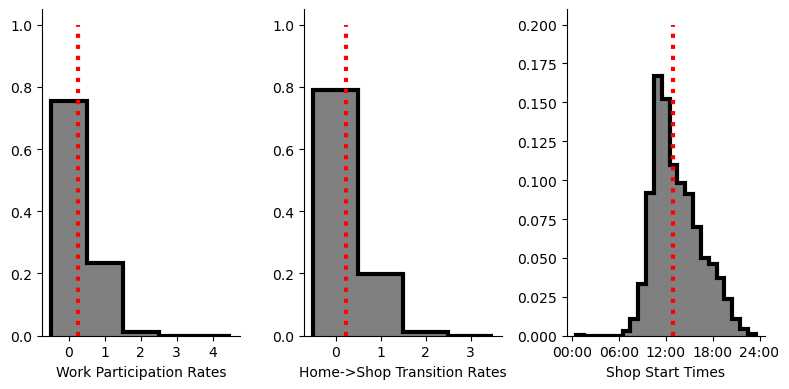

In [5]:
fs = 10
fig, ax = plt.subplots(1, 3, figsize=(8, 4), sharey=False)

act = "work"
bins, counts = participation.participation_rates_by_act(target_schedules)[act]
expected = np.average(bins, weights=counts) + 0.5
minimum = int(bins[0])
maximum = int(bins[-1])
bins = range(minimum, maximum + 2)
counts = counts / counts.sum()

ax[0].stairs(counts, bins, lw=3, ec="black", fc="grey", fill=True)
ax[0].vlines(expected, 0, 1, lw=3, ls=":", color="red")

bins = bins[:-1]
ticks = [i + 0.5 for i in bins]
ax[0].set_xticks(ticks, bins)
ax[0].set_xlabel("Work Participation Rates", fontsize=fs)

# =============
bins, counts = transitions.transitions_by_act(target_schedules)["home>shop"]
expected = np.average(bins, weights=counts) + 0.5
minimum = int(bins[0])
maximum = int(bins[-1])
bins = range(minimum, maximum + 2)
counts = counts / counts.sum()

ax[1].stairs(counts, bins, lw=3, ec="black", fc="grey", fill=True)
ax[1].vlines(expected, 0, 1, lw=3, ls=":", color="red")
bins = bins[:-1]
ticks = [i + 0.5 for i in bins]
ax[1].set_xticks(ticks, bins)
ax[1].set_xlabel("Home->Shop Transition Rates", fontsize=fs)

# =============

step = 60
act = "shop"
bins, counts = times.start_times_by_act(
    target_schedules, bin_size=step, factor=1
)[act]
expected = np.average(bins, weights=counts) + 0.5
counts = counts / counts.sum()
lookup = dict(zip(bins, counts))

target_bins = pd.Series([i for i in range(0, 1440, step)])
target_bins += step / 2

values = [0] * len(target_bins)

for i, b in enumerate(target_bins):
    values[i] = lookup.get(b, 0)

ax[2].stairs(values[:-1], target_bins, lw=3, fill=True, ec="black", fc="grey")
ax[2].vlines(expected, 0, 0.2, lw=3, ls=":", color="red")
bins = bins[:-1]
ticks = [i + 0.5 for i in bins]
ax[2].set_xticks(
    [0, 360, 720, 1080, 1440],
    labels=["00:00", "06:00", "12:00", "18:00", "24:00"],
    # rotation=90,
    fontsize=10,
)
ax[2].set_xlabel("Shop Start Times", fontsize=fs)

# remove outlines
for i in range(3):
    ax[i].spines["top"].set_visible(False)
    ax[i].spines["right"].set_visible(False)
    # ax[i].spines["left"].set_visible(False)
    # ax[i].spines["bottom"].set_visible(False)

fig.tight_layout()

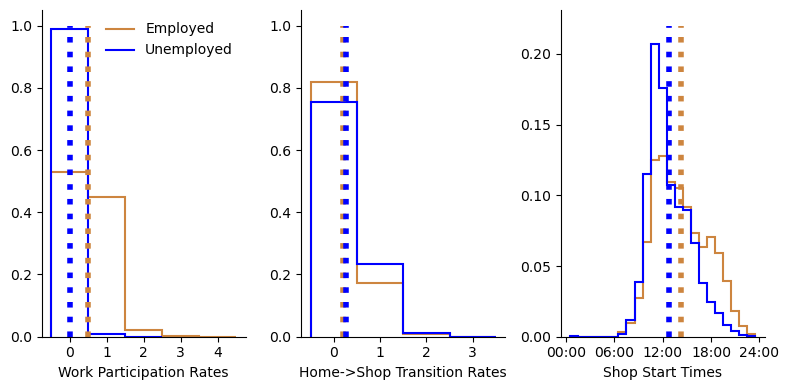

In [6]:
fs = 10
fig, ax = plt.subplots(1, 3, figsize=(8, 4), sharey=False)
split = split_on(target_schedules, target_attributes, by="work_status")
split = {
    # "Student": split["student"],
    "Employed": split["employed"],
    "Unemployed": split["unemployed"],
}
cmap2 = {"Employed": "peru", "Unemployed": "blue"}

act = "work"

for i, (k, v) in enumerate(split.items()):
    bins, counts = participation.participation_rates_by_act(v)[act]
    expected = np.average(bins, weights=counts) + 0.5
    minimum = int(bins[0])
    maximum = int(bins[-1])
    bins = range(minimum, maximum + 2)
    counts = counts / counts.sum()

    ax[0].stairs(counts, bins, lw=1.5, label=k, ls="-", color=cmap2[k])
    ax[0].vlines(expected, 0, 1, lw=4, ls=":", color=cmap2[k])

bins, counts = participation.participation_rates_by_act(target_schedules)[act]
minimum = int(bins[0])
maximum = int(bins[-1])
bins = range(minimum, maximum + 2)
bins = bins[:-1]
ticks = [i + 0.5 for i in bins]
ax[0].set_xticks(ticks, bins)
ax[0].set_xlabel(f"{act.title()} Participation Rates", fontsize=fs)

# =============
transition = "home>shop"

for i, (k, v) in enumerate(split.items()):
    bins, counts = transitions.transitions_by_act(v)[transition]
    expected = np.average(bins, weights=counts) + 0.5
    minimum = int(bins[0])
    maximum = int(bins[-1])
    bins = range(minimum, maximum + 2)
    counts = counts / counts.sum()

    ax[1].stairs(counts, bins, lw=1.5, label=k, ls="-", color=cmap2[k])
    ax[1].vlines(expected, 0, 1, lw=4, ls=":", color=cmap2[k])


bins = bins[:-1]
ticks = [i + 0.5 for i in bins]
ax[1].set_xticks(ticks, bins)
ax[1].set_xlabel("Home->Shop Transition Rates", fontsize=fs)

# =============

step = 60
act = "shop"

for i, (k, v) in enumerate(split.items()):

    bins, counts = times.start_times_by_act(v, bin_size=step, factor=1).get(
        act, (pd.Series([0]), pd.Series([0]))
    )
    expected = np.average(bins, weights=counts) + step / 2
    counts = counts / counts.sum()
    lookup = dict(zip(bins, counts))

    target_bins = pd.Series([i for i in range(0, 1440, step)])
    target_bins += step / 2

    values = [0] * len(target_bins)

    for i, b in enumerate(target_bins):
        values[i] = lookup.get(b, 0)

    ax[2].stairs(
        values[:-1], target_bins, lw=1.5, ls="-", label=k, color=cmap2[k]
    )
    ax[2].vlines(expected, 0, 0.22, lw=4, ls=":", color=cmap2[k])

bins = bins[:-1]
ticks = [i + 0.5 for i in bins]
ax[2].set_xticks(
    [0, 360, 720, 1080, 1440],
    labels=["00:00", "06:00", "12:00", "18:00", "24:00"],
    # rotation=90,
    fontsize=10,
)
ax[2].set_xlabel(f"{act.title()} Start Times", fontsize=fs)

ax[0].legend(loc="upper right", frameon=False)

# remove outlines
for i in range(3):
    ax[i].spines["top"].set_visible(False)
    ax[i].spines["right"].set_visible(False)

fig.tight_layout()

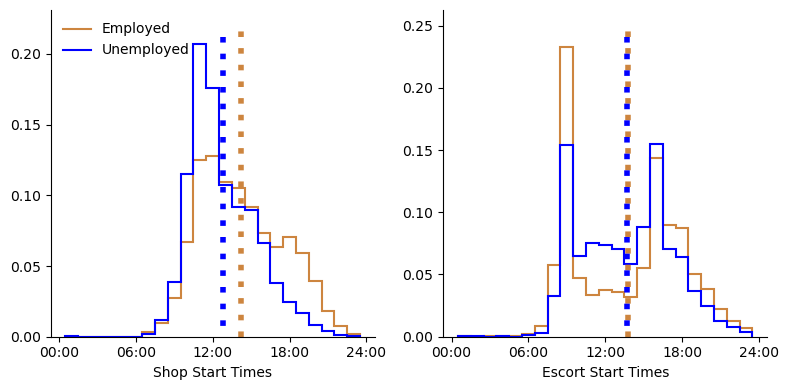

In [7]:
fs = 10
fig, ax = plt.subplots(1, 2, figsize=(8, 4), sharey=False)
split = split_on(target_schedules, target_attributes, by="work_status")
split = {
    # "Student": split["student"],
    "Employed": split["employed"],
    "Unemployed": split["unemployed"],
}
cmap2 = {"Employed": "peru", "Unemployed": "blue"}

step = 60
act = "shop"

for i, (k, v) in enumerate(split.items()):

    bins, counts = times.start_times_by_act(v, bin_size=step, factor=1).get(
        act, (pd.Series([0]), pd.Series([0]))
    )
    expected = np.average(bins, weights=counts) + step / 2
    counts = counts / counts.sum()
    lookup = dict(zip(bins, counts))

    target_bins = pd.Series([i for i in range(0, 1440, step)])
    target_bins += step / 2

    values = [0] * len(target_bins)

    for j, b in enumerate(target_bins):
        values[j] = lookup.get(b, 0)

    ax[0].stairs(
        values[:-1], target_bins, lw=1.5, ls="-", label=k, color=cmap2[k]
    )
    ax[0].vlines(expected, 0, 0.22, lw=4, ls=(i, (1, 2)), color=cmap2[k])

bins = bins[:-1]
ticks = [i + 0.5 for i in bins]
ax[0].set_xticks(
    [0, 360, 720, 1080, 1440],
    labels=["00:00", "06:00", "12:00", "18:00", "24:00"],
    # rotation=90,
    fontsize=10,
)
ax[0].set_xlabel(f"{act.title()} Start Times", fontsize=fs)

# =============
step = 60
act = "escort"

for i, (k, v) in enumerate(split.items()):

    bins, counts = times.start_times_by_act(v, bin_size=step, factor=1).get(
        act, (pd.Series([0]), pd.Series([0]))
    )
    expected = np.average(bins, weights=counts) + step / 2
    counts = counts / counts.sum()
    lookup = dict(zip(bins, counts))

    target_bins = pd.Series([i for i in range(0, 1440, step)])
    target_bins += step / 2

    values = [0] * len(target_bins)

    for j, b in enumerate(target_bins):
        values[j] = lookup.get(b, 0)

    ax[1].stairs(
        values[:-1], target_bins, lw=1.5, ls="-", label=k, color=cmap2[k]
    )
    ax[1].vlines(expected, 0, 0.25, lw=4, ls=(i, (1, 2)), color=cmap2[k])

bins = bins[:-1]
ticks = [i + 0.5 for i in bins]
ax[1].set_xticks(
    [0, 360, 720, 1080, 1440],
    labels=["00:00", "06:00", "12:00", "18:00", "24:00"],
    # rotation=90,
    fontsize=10,
)
ax[1].set_xlabel(f"{act.title()} Start Times", fontsize=fs)

ax[0].legend(loc="upper left", frameon=False)

# remove outlines
for i in range(2):
    ax[i].spines["top"].set_visible(False)
    ax[i].spines["right"].set_visible(False)

fig.tight_layout()

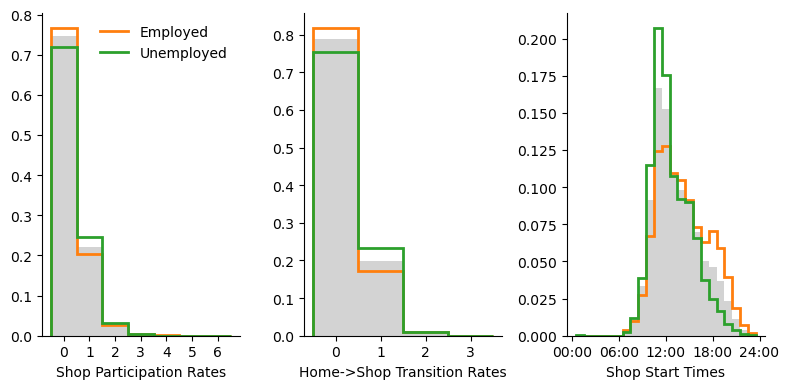

In [8]:
fs = 10
fig, ax = plt.subplots(1, 3, figsize=(8, 4), sharey=False)
split = split_on(target_schedules, target_attributes, by="work_status")
split = {
    # "Student": split["student"],
    "Employed": split["employed"],
    "Unemployed": split["unemployed"],
}


act = "shop"
bins, counts = participation.participation_rates_by_act(target_schedules)[act]
minimum = int(bins[0])
maximum = int(bins[-1])
bins = range(minimum, maximum + 2)
counts = counts / counts.sum()

ax[0].stairs(counts, bins, fc="lightgrey", fill=True)

for i, (k, v) in enumerate(split.items()):
    bins, counts = participation.participation_rates_by_act(v)[act]
    minimum = int(bins[0])
    maximum = int(bins[-1])
    bins = range(minimum, maximum + 2)
    counts = counts / counts.sum()

    ax[0].stairs(counts, bins, lw=2, label=k)

bins = bins[:-1]
ticks = [i + 0.5 for i in bins]
ax[0].set_xticks(ticks, bins)
ax[0].set_xlabel(f"{act.title()} Participation Rates", fontsize=fs)

# =============
transition = "home>shop"
bins, counts = transitions.transitions_by_act(target_schedules)[transition]

minimum = int(bins[0])
maximum = int(bins[-1])
bins = range(minimum, maximum + 2)
counts = counts / counts.sum()

ax[1].stairs(counts, bins, fc="lightgrey", fill=True)

for i, (k, v) in enumerate(split.items()):
    bins, counts = transitions.transitions_by_act(v)[transition]
    minimum = int(bins[0])
    maximum = int(bins[-1])
    bins = range(minimum, maximum + 2)
    counts = counts / counts.sum()
    ax[1].stairs(counts, bins, lw=2, label=k)


bins = bins[:-1]
ticks = [i + 0.5 for i in bins]
ax[1].set_xticks(ticks, bins)
ax[1].set_xlabel("Home->Shop Transition Rates", fontsize=fs)

# =============

step = 60
bins, counts = times.start_times_by_act(
    target_schedules, bin_size=step, factor=1
)[act]
counts = counts / counts.sum()
lookup = dict(zip(bins, counts))

target_bins = pd.Series([i for i in range(0, 1440, step)])
target_bins += step / 2

values = [0] * len(target_bins)

for i, b in enumerate(target_bins):
    values[i] = lookup.get(b, 0)

ax[2].stairs(values[:-1], target_bins, fill=True, fc="lightgrey")


for i, (k, v) in enumerate(split.items()):

    bins, counts = times.start_times_by_act(v, bin_size=step, factor=1).get(
        act, (pd.Series([0]), pd.Series([0]))
    )
    counts = counts / counts.sum()
    lookup = dict(zip(bins, counts))

    target_bins = pd.Series([i for i in range(0, 1440, step)])
    target_bins += step / 2

    values = [0] * len(target_bins)

    for i, b in enumerate(target_bins):
        values[i] = lookup.get(b, 0)

    ax[2].stairs(values[:-1], target_bins, lw=2, label=k)

bins = bins[:-1]
ticks = [i + 0.5 for i in bins]
ax[2].set_xticks(
    [0, 360, 720, 1080, 1440],
    labels=["00:00", "06:00", "12:00", "18:00", "24:00"],
    # rotation=90,
    fontsize=10,
)
ax[2].set_xlabel(f"{act.title()} Start Times", fontsize=fs)

ax[0].legend(loc="upper right", frameon=False)

# remove outlines
for i in range(3):
    ax[i].spines["top"].set_visible(False)
    ax[i].spines["right"].set_visible(False)
    # ax[i].spines["left"].set_visible(False)
    # ax[i].spines["bottom"].set_visible(False)

fig.tight_layout()

In [19]:
import ast


# losses
def iter_latest(path: Path):
    for dir in path.iterdir():
        if dir.is_dir():
            yield latest_run(dir)


def latest_run(path: Path):
    dirs = [
        p for p in path.iterdir() if p.is_dir() and p.name.startswith("version")
    ]
    return path.name, sorted(dirs)[-1]


def load_losses(path: Path):
    if not path.exists():
        return None
    with open(path) as f:
        lines = f.readlines()
    return lines


collected = pd.DataFrame()
for n, p in batch_paths.items():
    print(n)
    train_nll = []
    train_mse = []
    train_dkl = []
    test_nll = []
    test_mse = []
    test_dkl = []
    for name, m in iter_latest(p):
        loss_path = m / "best_loss.txt"
        losses = load_losses(loss_path)
        if losses is None:
            continue
        train_losses = ast.literal_eval(losses[0][7:])
        train_nll.append(
            train_losses["test_act_recon"] / train_losses["test_act_weight"]
        )
        train_mse.append(
            train_losses["test_dur_recon"] / train_losses["test_dur_weight"]
        )
        if "test_KLD" in train_losses:
            train_dkl.append(
                train_losses["test_KLD"] / train_losses["test_kld_weight"]
            )
        train_dkl.append(0)  # Placeholder for models without KLD

        test_losses = ast.literal_eval(losses[2][6:])
        test_nll.append(
            test_losses["test_act_recon"] / test_losses["test_act_weight"]
        )
        test_mse.append(
            test_losses["test_dur_recon"] / test_losses["test_dur_weight"]
        )
        if "test_KLD" in test_losses:
            test_dkl.append(
                test_losses["test_KLD"] / test_losses["test_kld_weight"]
            )
        test_dkl.append(0)  # Placeholder for models without KLD

    train_nll = np.array(train_nll)
    train_mse = np.array(train_mse)
    train_dkl = np.array(train_dkl)
    test_nll = np.array(test_nll)
    test_mse = np.array(test_mse)
    test_dkl = np.array(test_dkl)

    collected[(n, "mean")] = pd.Series(
        {
            "train_nll": train_nll.mean(),
            "train_mse": train_mse.mean(),
            "train_dkl": train_dkl.mean(),
            "test_nll": test_nll.mean(),
            "test_mse": test_mse.mean(),
            "test_dkl": test_dkl.mean(),
        }
    )
    collected[(n, "var")] = pd.Series(
        {
            "train_nll": train_nll.var(),
            "train_mse": train_mse.var(),
            "train_dkl": train_dkl.var(),
            "test_nll": test_nll.var(),
            "test_mse": test_mse.var(),
            "test_dkl": test_dkl.var(),
        }
    )

collected[collected.isnull()] = 0
print(collected[::-1].to_latex(float_format="{:.5f}".format))

ContRNNDiscrim
ContRNNGen
ActVAE
\begin{tabular}{lrrrrrr}
\toprule
 & ('ContRNNDiscrim', 'mean') & ('ContRNNDiscrim', 'var') & ('ContRNNGen', 'mean') & ('ContRNNGen', 'var') & ('ActVAE', 'mean') & ('ActVAE', 'var') \\
\midrule
test_dkl & 0.00000 & 0.00000 & 4.00919 & 16.13600 & 3.18268 & 10.13384 \\
test_mse & 0.00128 & 0.00000 & 0.00025 & 0.00000 & 0.00017 & 0.00000 \\
test_nll & 0.04806 & 0.00000 & 0.03976 & 0.00008 & 0.02704 & 0.00001 \\
train_dkl & 0.00000 & 0.00000 & 4.00489 & 16.10413 & 3.18110 & 10.12291 \\
train_mse & 0.00128 & 0.00000 & 0.00025 & 0.00000 & 0.00016 & 0.00000 \\
train_nll & 0.04815 & 0.00000 & 0.03959 & 0.00007 & 0.02628 & 0.00001 \\
\bottomrule
\end{tabular}



In [10]:
def build_distance_tables(batch_paths, suffix=""):
    distances_combined = pd.DataFrame()

    for name, path in batch_paths.items():
        distances = pd.read_csv(
            path / f"domain_distances{suffix}.csv"
        ).set_index("domain")

        columns = list(
            set(distances.columns) - set(["domain", "observed", "mean", "std"])
        )
        distances_combined[(name, "EMD")] = distances[columns].mean(axis=1)
        distances_combined[(name, "var")] = distances[columns].var(axis=1)

    distances_combined.columns = pd.MultiIndex.from_tuples(
        distances_combined.columns
    )

    # distances_combined = distances_combined.set_index(
    #     pd.MultiIndex.from_tuples(distances_combined.index)
    # )

    return distances_combined


order = ["participations", "transitions", "timing", "feasibility", "creativity"]
df = build_distance_tables(batch_paths, suffix="")
print(df.loc[order].to_latex(float_format="{:.3f}".format))

# conditional
df = build_distance_tables(batch_paths, suffix="_subs")
print(df.loc[order].to_latex(float_format="{:.3f}".format))
df

\begin{tabular}{lrrrrrr}
\toprule
 & \multicolumn{2}{r}{ContRNNDiscrim} & \multicolumn{2}{r}{ContRNNGen} & \multicolumn{2}{r}{ActVAE} \\
 & EMD & var & EMD & var & EMD & var \\
domain &  &  &  &  &  &  \\
\midrule
participations & 0.389 & 0.000 & 0.064 & 0.000 & 0.073 & 0.000 \\
transitions & 0.019 & 0.000 & 0.004 & 0.000 & 0.003 & 0.000 \\
timing & 0.172 & 0.000 & 0.024 & 0.000 & 0.029 & 0.000 \\
feasibility & 0.000 & 0.000 & 0.021 & 0.000 & 0.028 & 0.000 \\
creativity & 0.503 & 0.000 & 0.015 & 0.000 & 0.016 & 0.000 \\
\bottomrule
\end{tabular}

\begin{tabular}{lrrrrrr}
\toprule
 & \multicolumn{2}{r}{ContRNNDiscrim} & \multicolumn{2}{r}{ContRNNGen} & \multicolumn{2}{r}{ActVAE} \\
 & EMD & var & EMD & var & EMD & var \\
domain &  &  &  &  &  &  \\
\midrule
participations & 0.394 & 0.000 & 0.087 & 0.000 & 0.082 & 0.000 \\
transitions & 0.022 & 0.000 & 0.006 & 0.000 & 0.004 & 0.000 \\
timing & 0.180 & 0.000 & 0.032 & 0.000 & 0.031 & 0.000 \\
feasibility & 0.000 & 0.000 & 0.021 & 0.000 & 

ContRNNDiscrim           ContRNNGen                  ActVAE  \
                          EMD       var        EMD           var       EMD   
domain                                                                       
creativity           0.500285  0.000005   0.008703  3.272084e-06  0.009841   
feasibility          0.000000  0.000000   0.021185  1.427918e-05  0.027858   
participations       0.393511  0.000003   0.086501  1.454595e-04  0.081639   
timing               0.180158  0.000025   0.032384  8.027378e-06  0.030964   
transitions          0.022465  0.000002   0.006459  1.982260e-07  0.004490   

                              
                         var  
domain                        
creativity      1.548578e-06  
feasibility     1.068569e-04  
participations  1.261090e-04  
timing          1.286095e-06  
transitions     5.275949e-07

In [11]:
def group_tables(batch_paths, suffix=""):
    distances_combined = pd.DataFrame()
    descriptions_combined = pd.DataFrame()
    variances_combined = pd.DataFrame()

    for name, path in batch_paths.items():
        distances = pd.read_csv(
            path / f"group_distances{suffix}.csv"
        ).set_index(["domain", "feature"])
        descriptions = pd.read_csv(
            path / f"group_descriptions{suffix}.csv"
        ).set_index(["domain", "feature"])

        columns = set(distances.columns)
        columns = list(
            columns - set(["observed", "unit", "mean", "std", "sub_pop"])
        )

        print(name, columns)

        distances_combined[(name, "mean")] = distances[columns].mean(axis=1)
        distances_combined[(name, "var")] = distances[columns].var(axis=1)
        variances_combined[(name, "std")] = distances[columns].std(axis=1)
        descriptions_combined[(name, "mean")] = descriptions[columns].mean(
            axis=1
        )

    distances_combined.columns = pd.MultiIndex.from_tuples(
        distances_combined.columns
    )
    variances_combined.columns = pd.MultiIndex.from_tuples(
        variances_combined.columns
    )
    descriptions_combined.columns = pd.MultiIndex.from_tuples(
        descriptions_combined.columns
    )

    index = [
        "participations",
        "transitions",
        "timing",
        "feasibility",
        "creativity",
    ]

    return (
        distances_combined.loc[index],
        variances_combined,
        descriptions_combined.loc[index],
    )


dist_dist, dist_std, dist_desc = group_tables(batch_paths)
print(dist_dist.droplevel(0, axis=0).to_latex(float_format="{:.3f}".format))

# conditional
dist_dist, dist_std, dist_desc = group_tables(batch_paths, suffix="_subs")
print(dist_dist.droplevel(0, axis=0).to_latex(float_format="{:.3f}".format))

ContRNNDiscrim ['conditional_nrun3', 'conditional_nrun1', 'conditional_nrun2', 'conditional_nrun0', 'conditional_nrun4']
ContRNNGen ['vae_nrun4', 'vae_nrun3', 'vae_nrun1', 'vae_nrun2', 'vae_nrun0']
ActVAE ['cvae_nrun2', 'cvae_nrun0', 'cvae_nrun4', 'cvae_nrun3', 'cvae_nrun1']
\begin{tabular}{lrrrrrr}
\toprule
 & \multicolumn{2}{r}{ContRNNDiscrim} & \multicolumn{2}{r}{ContRNNGen} & \multicolumn{2}{r}{ActVAE} \\
 & mean & var & mean & var & mean & var \\
feature &  &  &  &  &  &  \\
\midrule
lengths & 0.955 & 0.000 & 0.160 & 0.002 & 0.185 & 0.001 \\
pair participation rate & 0.017 & 0.000 & 0.003 & 0.000 & 0.004 & 0.000 \\
participation rate & 0.195 & 0.000 & 0.029 & 0.000 & 0.031 & 0.000 \\
2-gram & 0.050 & 0.000 & 0.008 & 0.000 & 0.007 & 0.000 \\
3-gram & 0.006 & 0.000 & 0.002 & 0.000 & 0.002 & 0.000 \\
4-gram & 0.002 & 0.000 & 0.001 & 0.000 & 0.001 & 0.000 \\
durations & 0.100 & 0.000 & 0.015 & 0.000 & 0.019 & 0.000 \\
joint-durations & 0.245 & 0.000 & 0.038 & 0.000 & 0.044 & 0.000 \\


In [12]:
def build_all_description_tables(batch_paths):
    descriptions_combined = pd.DataFrame()

    for name, path in batch_paths.items():

        descriptions = pd.read_csv(path / "descriptions.csv").set_index(
            ["domain", "feature", "segment"]
        )
        distances = pd.read_csv(path / "distances.csv").set_index(
            ["domain", "feature", "segment"]
        )
        columns = set(descriptions.columns)
        weights = set([c for c in columns if "weight" in c])
        columns = list(
            columns
            - set(
                [
                    "observed",
                    "description",
                    "mean",
                    "std",
                    "feature count",
                    "unit",
                ]
            )
            - weights
        )
        descriptions_combined[name, "mean"] = descriptions[columns].mean(axis=1)
        # descriptions_combined[name, "var"] = descriptions[columns].var(axis=1)
        descriptions_combined[name, "EMD"] = distances[columns].mean(axis=1)

    descriptions_combined["Observed", ""] = descriptions["observed"]
    descriptions_combined["Description", ""] = descriptions["unit"]
    descriptions_combined.columns = pd.MultiIndex.from_tuples(
        descriptions_combined.columns
    )
    descriptions_combined = descriptions_combined.groupby(
        ["domain", "feature"], group_keys=False
    ).apply(
        lambda x: x.sort_values([("Observed", "")], ascending=False).head(20)
    )

    order = list(descriptions_combined.columns)
    order.pop(order.index(("Observed", "")))
    order = [("Observed", "")] + order

    index = [
        "participations",
        "transitions",
        "timing",
        "feasibility",
        "creativity",
    ]

    return descriptions_combined.loc[index, order]


table = build_all_description_tables(batch_paths)

p = table.loc["participations"]
for name in ["lengths", "participation rate", "pair participation rate"]:
    print(name)
    print(p.loc[name].to_latex(float_format="{:.3f}".format))
    print()

table.loc["participations"]

lengths
\begin{tabular}{lrrrrrrrl}
\toprule
 & Observed & \multicolumn{2}{r}{ContRNNDiscrim} & \multicolumn{2}{r}{ContRNNGen} & \multicolumn{2}{r}{ActVAE} & Description \\
 &  & mean & EMD & mean & EMD & mean & EMD &  \\
segment &  &  &  &  &  &  &  &  \\
\midrule
sequence lengths & 3.894 & 3.001 & 0.955 & 3.843 & 0.160 & 3.782 & 0.185 & length. \\
\bottomrule
\end{tabular}


participation rate
\begin{tabular}{lrrrrrrrl}
\toprule
 & Observed & \multicolumn{2}{r}{ContRNNDiscrim} & \multicolumn{2}{r}{ContRNNGen} & \multicolumn{2}{r}{ActVAE} & Description \\
 &  & mean & EMD & mean & EMD & mean & EMD &  \\
segment &  &  &  &  &  &  &  &  \\
\midrule
home & 2.306 & 2.001 & 0.337 & 2.270 & 0.055 & 2.263 & 0.060 & av. rate \\
other & 0.524 & 0.363 & 0.161 & 0.502 & 0.032 & 0.540 & 0.034 & av. rate \\
shop & 0.291 & 0.025 & 0.266 & 0.283 & 0.021 & 0.268 & 0.036 & av. rate \\
work & 0.256 & 0.471 & 0.238 & 0.257 & 0.019 & 0.260 & 0.013 & av. rate \\
escort & 0.256 & 0.007 & 0.249 & 0.232 & 0.0

Observed ContRNNDiscrim  \
                                                                mean   
feature                 segment                                        
lengths                 sequence lengths     3.893647       3.001309   
pair participation rate home+home            1.039079       1.000000   
                        other+other          0.086476       0.000000   
                        home+other           0.084029       0.000000   
                        escort+escort        0.075458       0.000655   
                        home+escort          0.072353       0.000655   
                        shop+shop            0.033325       0.000000   
                        home+shop            0.032701       0.000000   
                        visit+visit          0.013397       0.000000   
                        home+visit           0.013178       0.000000   
                        work+work            0.011221       0.000000   
                        home+work            0.011221       0.000000   
                        other+escort         0.004775       0.000000   
                        other+shop           0.002818       0.000000   
                        escort+shop          0.002160       0.000000   
                        other+visit          0.001873       0.000000   
                        home+medical         0.001603       0.000000   
                        medical+medical      0.001603       0.000000   
                        education+education  0.001164       0.000000   
                        home+education       0.001164       0.000000   
                        visit+shop           0.000945       0.000000   
participation rate      home                 2.306133       2.000655   
                        other                0.523766       0.362625   
                        shop                 0.291167       0.025384   
                        work                 0.256425       0.471287   
                        escort               0.256070       0.006854   
                        visit                0.127647       0.000000   
                        education            0.089581       0.134504   
                        medical              0.042858       0.000000   

                                                      ContRNNGen            \
                                                  EMD       mean       EMD   
feature                 segment                                              
lengths                 sequence lengths     0.954702   3.843381  0.160213   
pair participation rate home+home            0.070261   1.038114  0.020309   
                        other+other          0.086476   0.085092  0.005561   
                        home+other           0.084029   0.083449  0.004664   
                        escort+escort        0.074803   0.052841  0.022617   
                        home+escort          0.071698   0.050910  0.021443   
                        shop+shop            0.033325   0.035188  0.004725   
                        home+shop            0.032701   0.034452  0.004519   
                        visit+visit          0.013397   0.007411  0.007870   
                        home+visit           0.013178   0.007347  0.007708   
                        work+work            0.011221   0.014187  0.003682   
                        home+work            0.011221   0.014177  0.003692   
                        other+escort         0.004775   0.000256  0.004519   
                        other+shop           0.002818   0.000871  0.001947   
                        escort+shop          0.002160   0.000186  0.001974   
                        other+visit          0.001873   0.000152  0.001721   
                        home+medical         0.001603   0.001600  0.000989   
                        medical+medical      0.001603   0.001600  0.000989   
                        education+education  0.001164   0.001866  0.000945   
                        

In [13]:
def distance_weighted_av(
    report: DataFrame,
    base_col: str = "observed__weight",
    suffix: str = "__weight",
):
    """Weighted average of dataframe using weights in the weight column and a base column.
    This deals with cases where models have different features.
    """
    cols = list(report.columns)
    cols = [c for c in cols if not c.endswith(suffix)]
    base_weights = report[base_col]
    scores = DataFrame()
    for c in cols:
        weights = report[f"{c}{suffix}"]
        weights = (weights + base_weights) / 2
        total = weights.sum()
        scores[c] = report[c] * weights / total
    return scores.sum()


def build_labels_table(batch_paths):
    descriptions_combined = pd.DataFrame()

    for name, path in batch_paths.items():
        label_distances = pd.read_csv(
            path / "label_distances_subs.csv"
        ).set_index(["domain", "feature", "segment", "label"])

        columns = set(label_distances.columns)
        unit = label_distances["unit"].groupby(["domain", "label"]).first()

        columns = list(
            columns
            - set(
                [
                    # "observed",
                    "description",
                    "mean",
                    "std",
                    "feature count",
                    "unit",
                    "cat",
                    "label",
                    "domain",
                    "feature",
                    "segment",
                ]
            )
        )
        label_distances = (
            label_distances[columns]
            .groupby(["domain", "label"])
            .apply(distance_weighted_av)
        )

        descriptions_combined[name, "EMD"] = label_distances.mean(axis=1)
        descriptions_combined[name, "var"] = label_distances.var(axis=1)

    descriptions_combined["Description", ""] = unit
    descriptions_combined.columns = pd.MultiIndex.from_tuples(
        descriptions_combined.columns
    )

    order = list(descriptions_combined.columns)

    index = ["participations", "transitions", "timing"]

    return descriptions_combined.loc[index, order]


table = build_labels_table(batch_paths)
print(table.to_latex(float_format="{:.3f}".format))


table

/tmp/ipykernel_843227/3185359006.py:25: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  label_distances = pd.read_csv(
/tmp/ipykernel_843227/3185359006.py:25: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  label_distances = pd.read_csv(


\begin{tabular}{llrrrrrrl}
\toprule
 &  & \multicolumn{2}{r}{ContRNNDiscrim} & \multicolumn{2}{r}{ContRNNGen} & \multicolumn{2}{r}{ActVAE} & Description \\
 &  & EMD & var & EMD & var & EMD & var &  \\
domain & label &  &  &  &  &  &  &  \\
\midrule
\multirow[t]{5}{*}{participations} & age_group & 0.116 & 0.002 & 0.059 & 0.005 & 0.050 & 0.006 & EMD \\
 & car_access & 0.103 & 0.003 & 0.047 & 0.006 & 0.047 & 0.006 & EMD \\
 & gender & 0.101 & 0.003 & 0.044 & 0.006 & 0.045 & 0.006 & EMD \\
 & income & 0.103 & 0.003 & 0.046 & 0.006 & 0.046 & 0.006 & EMD \\
 & work_status & 0.110 & 0.002 & 0.052 & 0.006 & 0.046 & 0.006 & EMD \\
\cline{1-9}
\multirow[t]{5}{*}{transitions} & age_group & 0.014 & 0.000 & 0.007 & 0.000 & 0.005 & 0.000 & EMD \\
 & car_access & 0.007 & 0.000 & 0.003 & 0.000 & 0.003 & 0.000 & EMD \\
 & gender & 0.008 & 0.000 & 0.003 & 0.000 & 0.003 & 0.000 & EMD \\
 & income & 0.010 & 0.000 & 0.004 & 0.000 & 0.004 & 0.000 & EMD \\
 & work_status & 0.010 & 0.000 & 0.005 & 0.000 & 0.

ContRNNDiscrim               ContRNNGen            \
                                      EMD           var        EMD       var   
domain         label                                                           
participations age_group         0.115880  2.135084e-03   0.059018  0.005474   
               car_access        0.103071  2.560495e-03   0.047203  0.006074   
               gender            0.100702  2.674714e-03   0.044336  0.006293   
               income            0.102595  2.579187e-03   0.046178  0.006150   
               work_status       0.110288  2.221591e-03   0.051716  0.005733   
transitions    age_group         0.013524  1.695702e-06   0.007140  0.000004   
               car_access        0.007280  7.436308e-07   0.003029  0.000003   
               gender            0.008037  3.908379e-07   0.003150  0.000004   
               income            0.010292  6.323774e-07   0.004076  0.000006   
               work_status       0.010496  1.546078e-06   0.004840  0.000003   
timing         age_group         0.228441  1.197224e-02   0.110984  0.027870   
               car_access        0.219637  1.301337e-02   0.097191  0.030174   
               gender            0.215448  1.341740e-02   0.095638  0.030440   
               income            0.218475  1.307123e-02   0.097866  0.030058   
               work_status       0.221844  1.270063e-02   0.104827  0.028887   

                              ActVAE           Description  
                                 EMD       var              
domain         label                                        
participations age_group    0.050135  0.006140         EMD  
               car_access   0.046998  0.006094         EMD  
               gender       0.045192  0.006229         EMD  
               income       0.045957  0.006170         EMD  
               work_status  0.046114  0.006159         EMD  
transitions    age_group    0.005466  0.000008         EMD  
               car_access   0.002876  0.000004         EMD  
               gender       0.002982  0.000004         EMD  
               income       0.003831  0.000007         EMD  
               work_status  0.003564  0.000005         EMD  
timing         age_group    0.103341  0.029130         EMD  
               car_access   0.099445  0.029785         EMD  
               gender       0.098550  0.029937         EMD  
               income       0.099359  0.029800         EMD  
               work_status  0.099787  0.029728         EMD

In [14]:
def build_all_description_tables_subs_fixed(batch_paths, on="work_status"):
    descriptions_combined = pd.DataFrame()

    for name, path in batch_paths.items():
        label_descriptions = pd.read_csv(path / "label_descriptions_subs.csv")
        label_distances = pd.read_csv(path / "label_distances_subs.csv")

        descriptions = pd.read_csv(path / "descriptions_subs.csv")

        columns = set(label_descriptions.columns)
        columns = list(
            columns
            - set(
                [
                    "label",
                    "cat",
                    "description",
                    "mean",
                    "std",
                    "feature count",
                    "unit",
                ]
            )
        )

        distances = (
            label_distances[columns]
            .loc[label_distances.label == on]
            .set_index(["domain", "feature", "segment"])
            .groupby(["domain", "feature", "segment"])
            .apply(distance_weighted_av)
        ).reset_index()
        descriptions["label"] = on
        distances["label"] = on
        descriptions["cat"] = "combined"
        distances["cat"] = "combined"

        columns = set(distances.columns)
        weights = set([c for c in columns if "weight" in c])
        columns = list(
            columns
            - set(
                [
                    "observed",
                    "description",
                    "mean",
                    "std",
                    "feature count",
                    "unit",
                ]
            )
            - weights
        )
        distances = distances[columns]

        label_descriptions = pd.concat((label_descriptions, descriptions))
        label_distances = pd.concat((label_distances, distances))

        label_descriptions = (
            label_descriptions.loc[label_descriptions.label == on]
            .drop("label", axis=1)
            .set_index(["domain", "feature", "segment", "cat"])
        )
        label_distances = (
            label_distances.loc[label_distances.label == on]
            .drop("label", axis=1)
            .set_index(["domain", "feature", "segment", "cat"])
        )

        columns = set(label_descriptions.columns)
        weights = set([c for c in columns if "weight" in c])
        columns = list(
            columns
            - set(
                [
                    "observed",
                    "description",
                    "mean",
                    "std",
                    "feature count",
                    "unit",
                ]
            )
            - weights
        )

        observed = label_descriptions["observed"]
        unit = label_descriptions["unit"]

        label_descriptions = label_descriptions[columns]
        label_distances = label_distances[columns]

        descriptions_combined[name, "mean"] = label_descriptions.mean(axis=1)
        descriptions_combined[name, "EMD"] = label_distances.mean(axis=1)

    descriptions_combined["Observed", ""] = observed
    descriptions_combined["Description", ""] = unit
    descriptions_combined.columns = pd.MultiIndex.from_tuples(
        descriptions_combined.columns
    )
    descriptions_combined["maxi"] = descriptions_combined.Observed.groupby(
        ["domain", "feature", "segment"], group_keys=False
    ).transform("max")
    descriptions_combined = descriptions_combined.sort_values(
        ["maxi"], ascending=False
    ).drop(columns=["maxi"])

    descriptions_combined = descriptions_combined.groupby(
        ["domain", "feature"], group_keys=False
    ).apply(lambda x: x.head(1000))

    order = list(descriptions_combined.columns)
    order.pop(order.index(("Observed", "")))
    order = [("Observed", "")] + order

    index = [
        "participations",
        "transitions",
        "timing",
        "feasibility",
        "creativity",
    ]

    return descriptions_combined.loc[index, order]


table = build_all_description_tables_subs_fixed(batch_paths)

p = table.loc["participations"]
for name in ["lengths", "participation rate"]:
    print(name)
    pp = p.loc[name]
    pp.loc[:, "Description"] = "rate"
    print(pp.to_latex(float_format="{:.3f}".format))
    print()

/tmp/ipykernel_843227/3814685357.py:5: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  label_descriptions = pd.read_csv(path / "label_descriptions_subs.csv")
/tmp/ipykernel_843227/3814685357.py:6: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  label_distances = pd.read_csv(path / "label_distances_subs.csv")
/tmp/ipykernel_843227/3814685357.py:5: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  label_descriptions = pd.read_csv(path / "label_descriptions_subs.csv")
/tmp/ipykernel_843227/3814685357.py:6: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  label_distances = pd.read_csv(path / "label_distances_subs.csv")


lengths
\begin{tabular}{llrrrrrrrl}
\toprule
 &  & Observed & \multicolumn{2}{r}{ContRNNDiscrim} & \multicolumn{2}{r}{ContRNNGen} & \multicolumn{2}{r}{ActVAE} & Description \\
 &  &  & mean & EMD & mean & EMD & mean & EMD &  \\
segment & cat &  &  &  &  &  &  &  &  \\
\midrule
\multirow[t]{4}{*}{sequence lengths} & unemployed & 3.823 & 3.003 & 0.881 & 3.845 & 0.140 & 3.742 & 0.153 & rate \\
 & employed & 3.979 & 3.000 & 1.042 & 3.842 & 0.207 & 3.830 & 0.223 & rate \\
 & student & 3.475 & 3.000 & 0.555 & 3.845 & 0.383 & 3.562 & 0.182 & rate \\
 & combined & 3.894 & 3.001 & 0.955 & 3.843 & 0.180 & 3.782 & 0.189 & rate \\
\cline{1-10}
\bottomrule
\end{tabular}


participation rate
\begin{tabular}{llrrrrrrrl}
\toprule
 &  & Observed & \multicolumn{2}{r}{ContRNNDiscrim} & \multicolumn{2}{r}{ContRNNGen} & \multicolumn{2}{r}{ActVAE} & Description \\
 &  &  & mean & EMD & mean & EMD & mean & EMD &  \\
segment & cat &  &  &  &  &  &  &  &  \\
\midrule
\multirow[t]{4}{*}{home} & combined & 2.306

/tmp/ipykernel_843227/3814685357.py:106: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  ).drop(columns=["maxi"])


In [15]:
table = build_all_description_tables_subs_fixed(batch_paths, on="gender")
t = table.loc["transitions"]
acts = [
    "home>other",
    "home>work",
    "home>education",
    "home>shop",
    "home>visit",
    "home>escort",
    "home>medical",
]
data = []
for act in acts:
    tt = t.loc["2-gram"]
    tt.loc[:, "Description"] = "rate"
    tt = tt.loc[([act]),]
    data.append(tt)
data = pd.concat(data)
data = data.sort_index(ascending=False)
print(data.to_latex(float_format="{:.3f}".format))
data

/tmp/ipykernel_843227/3814685357.py:5: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  label_descriptions = pd.read_csv(path / "label_descriptions_subs.csv")
/tmp/ipykernel_843227/3814685357.py:6: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  label_distances = pd.read_csv(path / "label_distances_subs.csv")
/tmp/ipykernel_843227/3814685357.py:5: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  label_descriptions = pd.read_csv(path / "label_descriptions_subs.csv")
/tmp/ipykernel_843227/3814685357.py:6: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  label_distances = pd.read_csv(path / "label_distances_subs.csv")


\begin{tabular}{llrrrrrrrl}
\toprule
 &  & Observed & \multicolumn{2}{r}{ContRNNDiscrim} & \multicolumn{2}{r}{ContRNNGen} & \multicolumn{2}{r}{ActVAE} & Description \\
 &  &  & mean & EMD & mean & EMD & mean & EMD &  \\
segment & cat &  &  &  &  &  &  &  &  \\
\midrule
\multirow[t]{3}{*}{home>work} & combined & 0.243 & 0.543 & 0.246 & 0.225 & 0.028 & 0.238 & 0.016 & rate \\
 & M & 0.263 & 0.490 & 0.239 & 0.224 & 0.043 & 0.250 & 0.018 & rate \\
 & F & 0.216 & 0.454 & 0.252 & 0.226 & 0.013 & 0.226 & 0.013 & rate \\
\cline{1-10}
\multirow[t]{3}{*}{home>visit} & combined & 0.095 & 0.000 & 0.095 & 0.107 & 0.016 & 0.106 & 0.017 & rate \\
 & M & 0.086 & 0.000 & 0.086 & 0.107 & 0.023 & 0.101 & 0.017 & rate \\
 & F & 0.103 & 0.000 & 0.103 & 0.108 & 0.010 & 0.111 & 0.018 & rate \\
\cline{1-10}
\multirow[t]{3}{*}{home>shop} & combined & 0.221 & 0.035 & 0.196 & 0.206 & 0.020 & 0.196 & 0.028 & rate \\
 & M & 0.213 & 0.018 & 0.196 & 0.207 & 0.013 & 0.189 & 0.026 & rate \\
 & F & 0.228 & 0.033 & 0.19

/tmp/ipykernel_843227/3814685357.py:106: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  ).drop(columns=["maxi"])


Observed ContRNNDiscrim           ContRNNGen  \
                                            mean       EMD       mean   
segment        cat                                                      
home>work      combined  0.243422       0.543374  0.245959   0.225211   
               M         0.262795       0.489509  0.239080   0.224362   
               F         0.216067       0.454469  0.252302   0.225996   
home>visit     combined  0.094805       0.000000  0.094805   0.107464   
               M         0.086347       0.000000  0.086347   0.107214   
               F         0.102599       0.000000  0.102599   0.107694   
home>shop      combined  0.221097       0.034974  0.195707   0.206082   
               M         0.213117       0.017536  0.195580   0.206935   
               F         0.228451       0.032627  0.195824   0.205294   
home>other     combined  0.450335       0.370466  0.092375   0.406103   
               M         0.459721       0.359809  0.107568   0.405967   
               F         0.441685       0.365225  0.078363   0.406229   
home>medical   combined  0.037582       0.000000  0.037572   0.048372   
               M         0.033417       0.000000  0.033417   0.048089   
               F         0.041402       0.000000  0.041402   0.048633   
home>escort    combined  0.198197       0.010339  0.191721   0.176056   
               M         0.179950       0.001870  0.178080   0.175011   
               F         0.215013       0.011453  0.203559   0.177020   
home>education combined  0.086337       0.160724  0.049471   0.090878   
               M         0.086347       0.131275  0.046429   0.090234   
               F         0.086328       0.137484  0.052276   0.091473   

                                     ActVAE           Description  
                              EMD      mean       EMD              
segment        cat                                                 
home>work      combined  0.027592  0.237801  0.015536        rate  
               M         0.042877  0.250468  0.017889        rate  
               F         0.013495  0.226114  0.013366        rate  
home>visit     combined  0.016411  0.106425  0.017229        rate  
               M         0.022998  0.101177  0.016925        rate  
               F         0.010336  0.111267  0.017509        rate  
home>shop      combined  0.019529  0.196382  0.027587        rate  
               M         0.013060  0.189024  0.025579        rate  
               F         0.025495  0.203173  0.029438        rate  
home>other     combined  0.044235  0.446399  0.020492        rate  
               M         0.053754  0.451781  0.017947        rate  
               F         0.035456  0.441427  0.022839        rate  
home>medical   combined  0.011419  0.032279  0.009674        rate  
               M         0.015130  0.030141  0.009227        rate  
               F         0.007996  0.034246  0.010086        rate  
home>escort    combined  0.041739  0.152104  0.046087        rate  
               M         0.038796  0.146990  0.032960        rate  
               F         0.044454  0.156822  0.058191        rate  
home>education combined  0.012951  0.078870  0.009062        rate  
               M         0.012900  0.079638  0.008272        rate  
               F         0.012999  0.078162  0.009789        rate

In [16]:
table = build_all_description_tables_subs_fixed(batch_paths, on="car_access")
t = table.loc["timing"]
acts = ["work0", "education0", "shop0", "home0", "visit0", "home1"]
data = []
for act in acts:
    tt = t.loc["start times"]
    tt.loc[:, "Description"] = "days"
    tt = tt.loc[([act]),]
    data.append(tt)
data = pd.concat(data)
data = data.sort_index(ascending=False)
print(data.to_latex(float_format="{:.3f}".format))

data = []
for act in acts:
    tt = t.loc["durations"]
    tt.loc[:, "Description"] = "days"
    tt = tt.loc[([act]),]
    data.append(tt)
data = pd.concat(data)
data = data.sort_index(ascending=False)
print(data.to_latex(float_format="{:.3f}".format))

/tmp/ipykernel_843227/3814685357.py:5: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  label_descriptions = pd.read_csv(path / "label_descriptions_subs.csv")
/tmp/ipykernel_843227/3814685357.py:6: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  label_distances = pd.read_csv(path / "label_distances_subs.csv")
/tmp/ipykernel_843227/3814685357.py:5: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  label_descriptions = pd.read_csv(path / "label_descriptions_subs.csv")
/tmp/ipykernel_843227/3814685357.py:6: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  label_distances = pd.read_csv(path / "label_distances_subs.csv")


\begin{tabular}{llrrrrrrrl}
\toprule
 &  & Observed & \multicolumn{2}{r}{ContRNNDiscrim} & \multicolumn{2}{r}{ContRNNGen} & \multicolumn{2}{r}{ActVAE} & Description \\
 &  &  & mean & EMD & mean & EMD & mean & EMD &  \\
segment & cat &  &  &  &  &  &  &  &  \\
\midrule
\multirow[t]{4}{*}{work0} & yes & 0.362 & 0.511 & 0.161 & 0.383 & 0.025 & 0.381 & 0.024 & days \\
 & unknown & 0.347 & 0.458 & 0.137 & 0.377 & 0.051 & 0.389 & 0.061 & days \\
 & no & 0.382 & 0.476 & 0.118 & 0.383 & 0.016 & 0.395 & 0.020 & days \\
 & combined & 0.365 & 0.508 & 0.156 & 0.383 & 0.024 & 0.382 & 0.024 & days \\
\cline{1-10}
\multirow[t]{4}{*}{visit0} & yes & 0.562 & 0.000 & 0.562 & 0.566 & 0.013 & 0.558 & 0.018 & days \\
 & unknown & 0.641 & 0.000 & 0.641 & 0.552 & 0.108 & 0.497 & 0.150 & days \\
 & no & 0.553 & 0.000 & 0.553 & 0.567 & 0.024 & 0.557 & 0.018 & days \\
 & combined & 0.562 & 0.000 & 0.562 & 0.566 & 0.014 & 0.558 & 0.018 & days \\
\cline{1-10}
\multirow[t]{4}{*}{shop0} & yes & 0.532 & 0.219 & 0.3

/tmp/ipykernel_843227/3814685357.py:106: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  ).drop(columns=["maxi"])


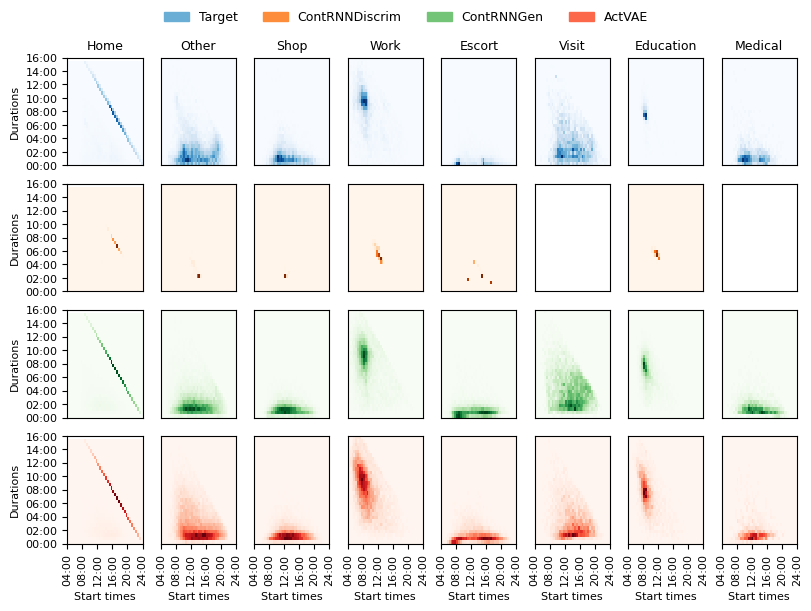

In [16]:
fig = joint_time_distributions_plot(
    target_schedules,
    schedules,
    figsize=(8, 6),
    observed_title="Target",
    cmaps={
        0: "Blues",
        1: "Oranges",
        2: "Greens",
        3: "Reds",
        4: "Purples",
        5: "Greys",
    },
)

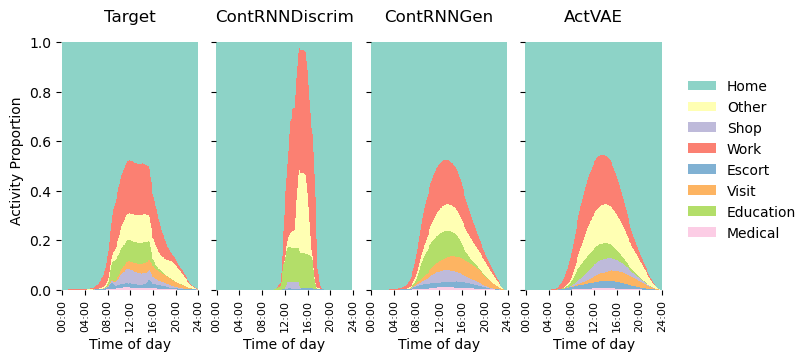

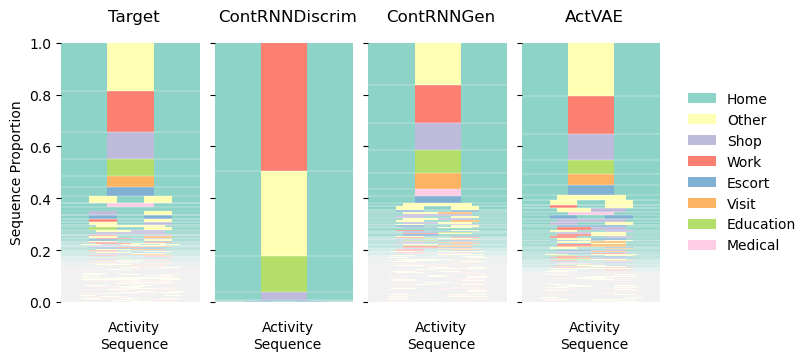

In [17]:
# fig = times_distributions_plot(
#     target_schedules, schedules, observed_title="Target", figsize=(9, 5)
# )
fig = frequency_plots(
    target_schedules,
    schedules,
    color=cmap,
    figsize=(8, 3.5),
    observed_title="Target",
)
fig = sequence_prob_plot(
    target_schedules,
    schedules,
    cmap=cmap,
    figsize=(8, 3.5),
    observed_title="Target",
)

In [19]:
import random

from pam.core import Household, Person
from pam.plot.plans import plot_household

from caveat.data.utils import trace_to_pam


def stretch(schedules):
    return schedules.groupby(schedules.pid).apply(stretcher)


def stretcher(schedule):
    duration = schedule.duration.sum()
    if duration != 1440:
        a = 1440 / duration
        schedule.duration = (schedule.duration * a).astype(int)
        accumulated = list(schedule.duration.cumsum())
        schedule.start = [0] + accumulated[:-1]
        schedule.end = accumulated
    return schedule


def trim(schedules):
    schedules[schedules.end > 1440] = 1440
    schedules[schedules.start > 1440] = 1440
    schedules.duration = schedules.end - schedules.start
    schedules = schedules[schedules.duration > 0]
    return schedules


def pad(schedules):
    return (
        schedules.groupby(schedules["pid"]).apply(padder).reset_index(drop=True)
    )


def padder(schedule):
    if schedule.end.iloc[-1] < 1440 and schedule.act.iloc[-1] != "home":
        pid = schedule.pid.iloc[0]
        schedule = pd.concat(
            [
                schedule,
                DataFrame(
                    {
                        "pid": pid,
                        "start": schedule.end.iloc[-1],
                        "end": 1440,
                        "duration": 1440 - schedule.end.iloc[-1],
                        "act": "home",
                    },
                    index=[0],
                ),
            ]
        )
    elif schedule.end.iloc[-1] < 1440:
        schedule.end.iloc[-1] = 1440
        schedule.duration.iloc[-1] = 1440 - schedule.start.iloc[-1]
    return schedule


def plot_schedules(schedules, **kwargs):
    cmap = {
        "home": (0.5529411764705883, 0.8274509803921568, 0.7803921568627451),
        "other": (1.0, 1.0, 0.7019607843137254),
        "shop": (0.7450980392156863, 0.7294117647058823, 0.8549019607843137),
        "work": (0.984313725490196, 0.5019607843137255, 0.4470588235294118),
        "escort": (0.5019607843137255, 0.6941176470588235, 0.8274509803921568),
        "visit": (0.9921568627450981, 0.7058823529411765, 0.3843137254901961),
        "education": (
            0.7019607843137254,
            0.8705882352941177,
            0.4117647058823529,
        ),
        "medical": (0.9882352941176471, 0.803921568627451, 0.8980392156862745),
        "travel": (0.8509803921568627, 0.8509803921568627, 0.8509803921568627),
    }
    cmap = {n.title(): c for n, c in cmap.items()}

    hh = Household("")
    pids = schedules.pid
    selected = random.sample(list(pids), 8)
    for i, pid in enumerate(selected):
        person = Person(pid)
        plan = schedules[schedules.pid == pid]
        plan = trim(stretch(pad(plan)))[["act", "start", "end", "duration"]]
        mapping = {a: a for a in plan.act}

        trace = [
            (row.act, row.start, row.end, row.duration)
            for i, row in plan.iterrows()
        ]
        plan = trace_to_pam(trace, mapping)

        person = Person(i)
        person.plan = plan
        hh.add(person)

    plot_household(hh, cmap=cmap, width=25)

/tmp/ipykernel_843227/3145219427.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  schedules.groupby(schedules["pid"]).apply(padder).reset_index(drop=True)
/tmp/ipykernel_843227/3145219427.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return schedules.groupby(schedules.pid).apply(stretcher)
/tmp/ipykernel_843227/3145219427.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping 

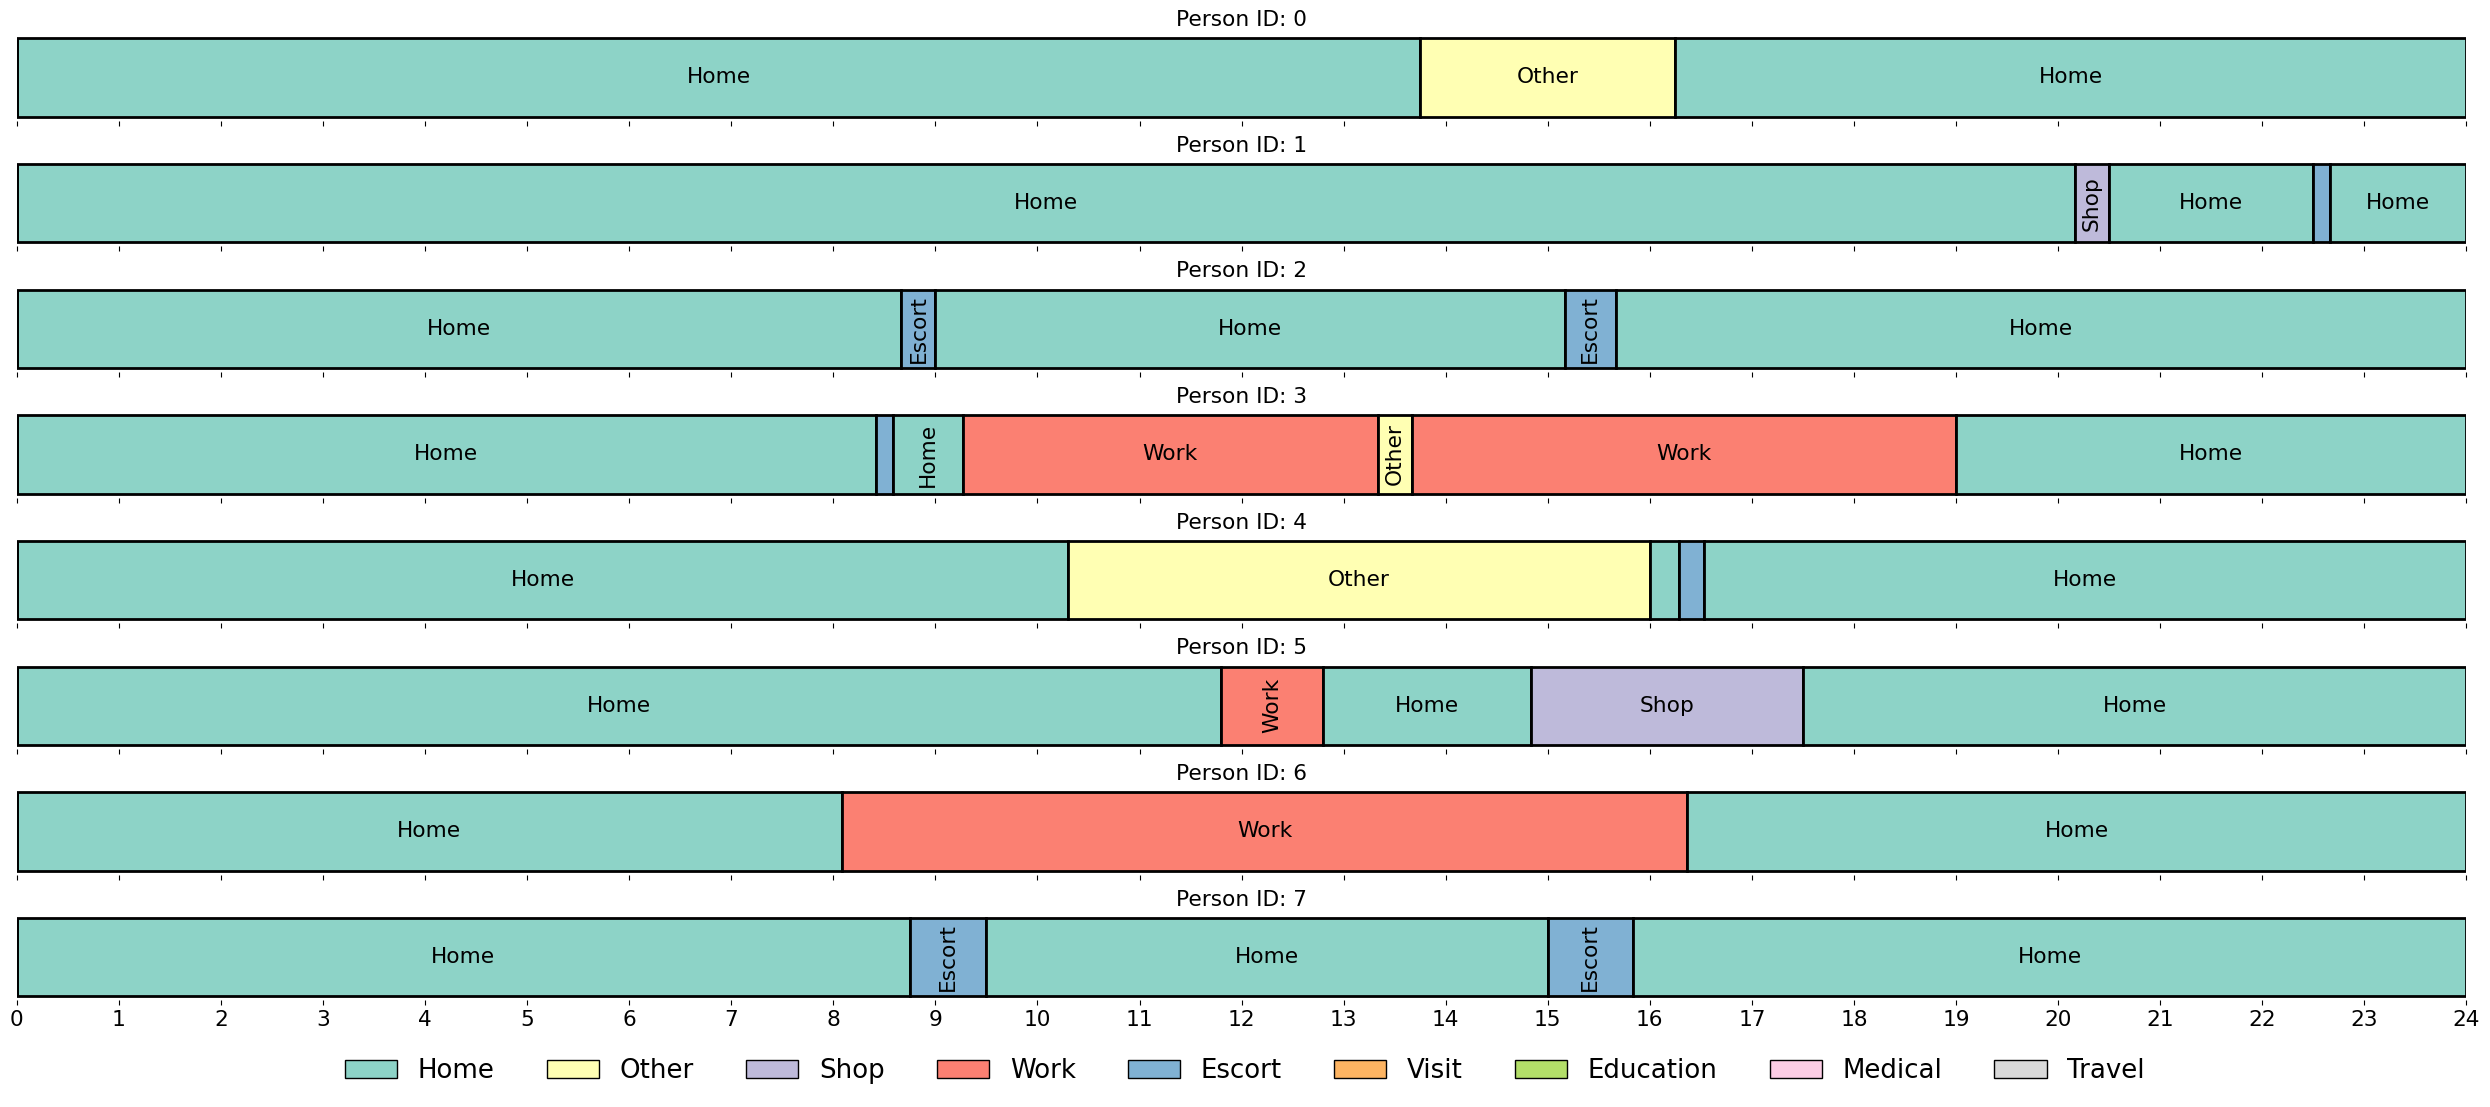

In [20]:
plot_schedules(target_schedules)

/tmp/ipykernel_843227/3145219427.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  schedules.groupby(schedules["pid"]).apply(padder).reset_index(drop=True)
/tmp/ipykernel_843227/3145219427.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return schedules.groupby(schedules.pid).apply(stretcher)
/tmp/ipykernel_843227/3145219427.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping 

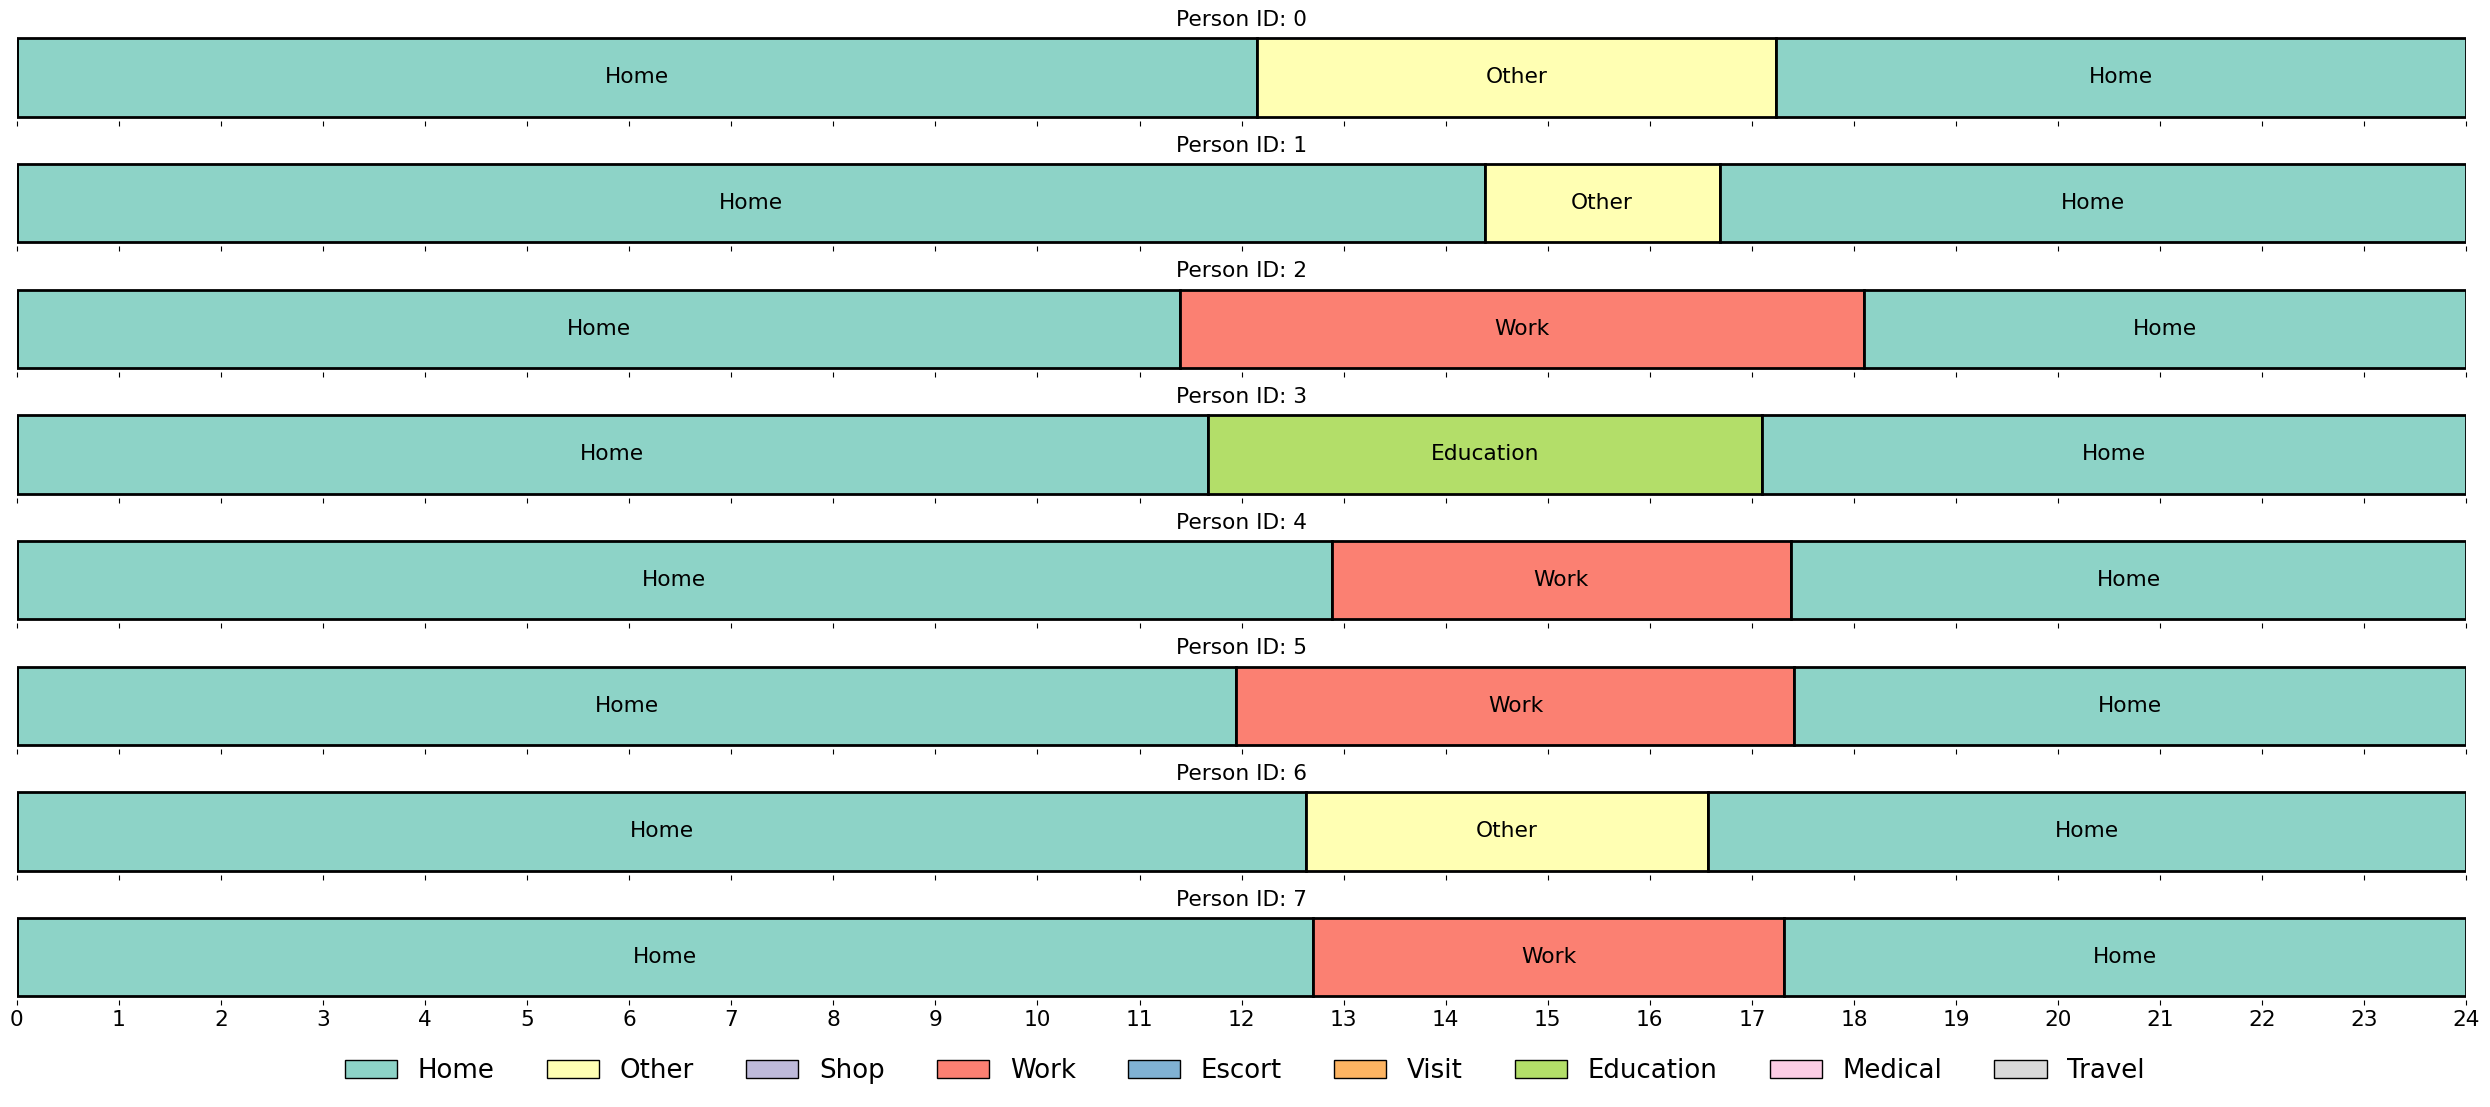

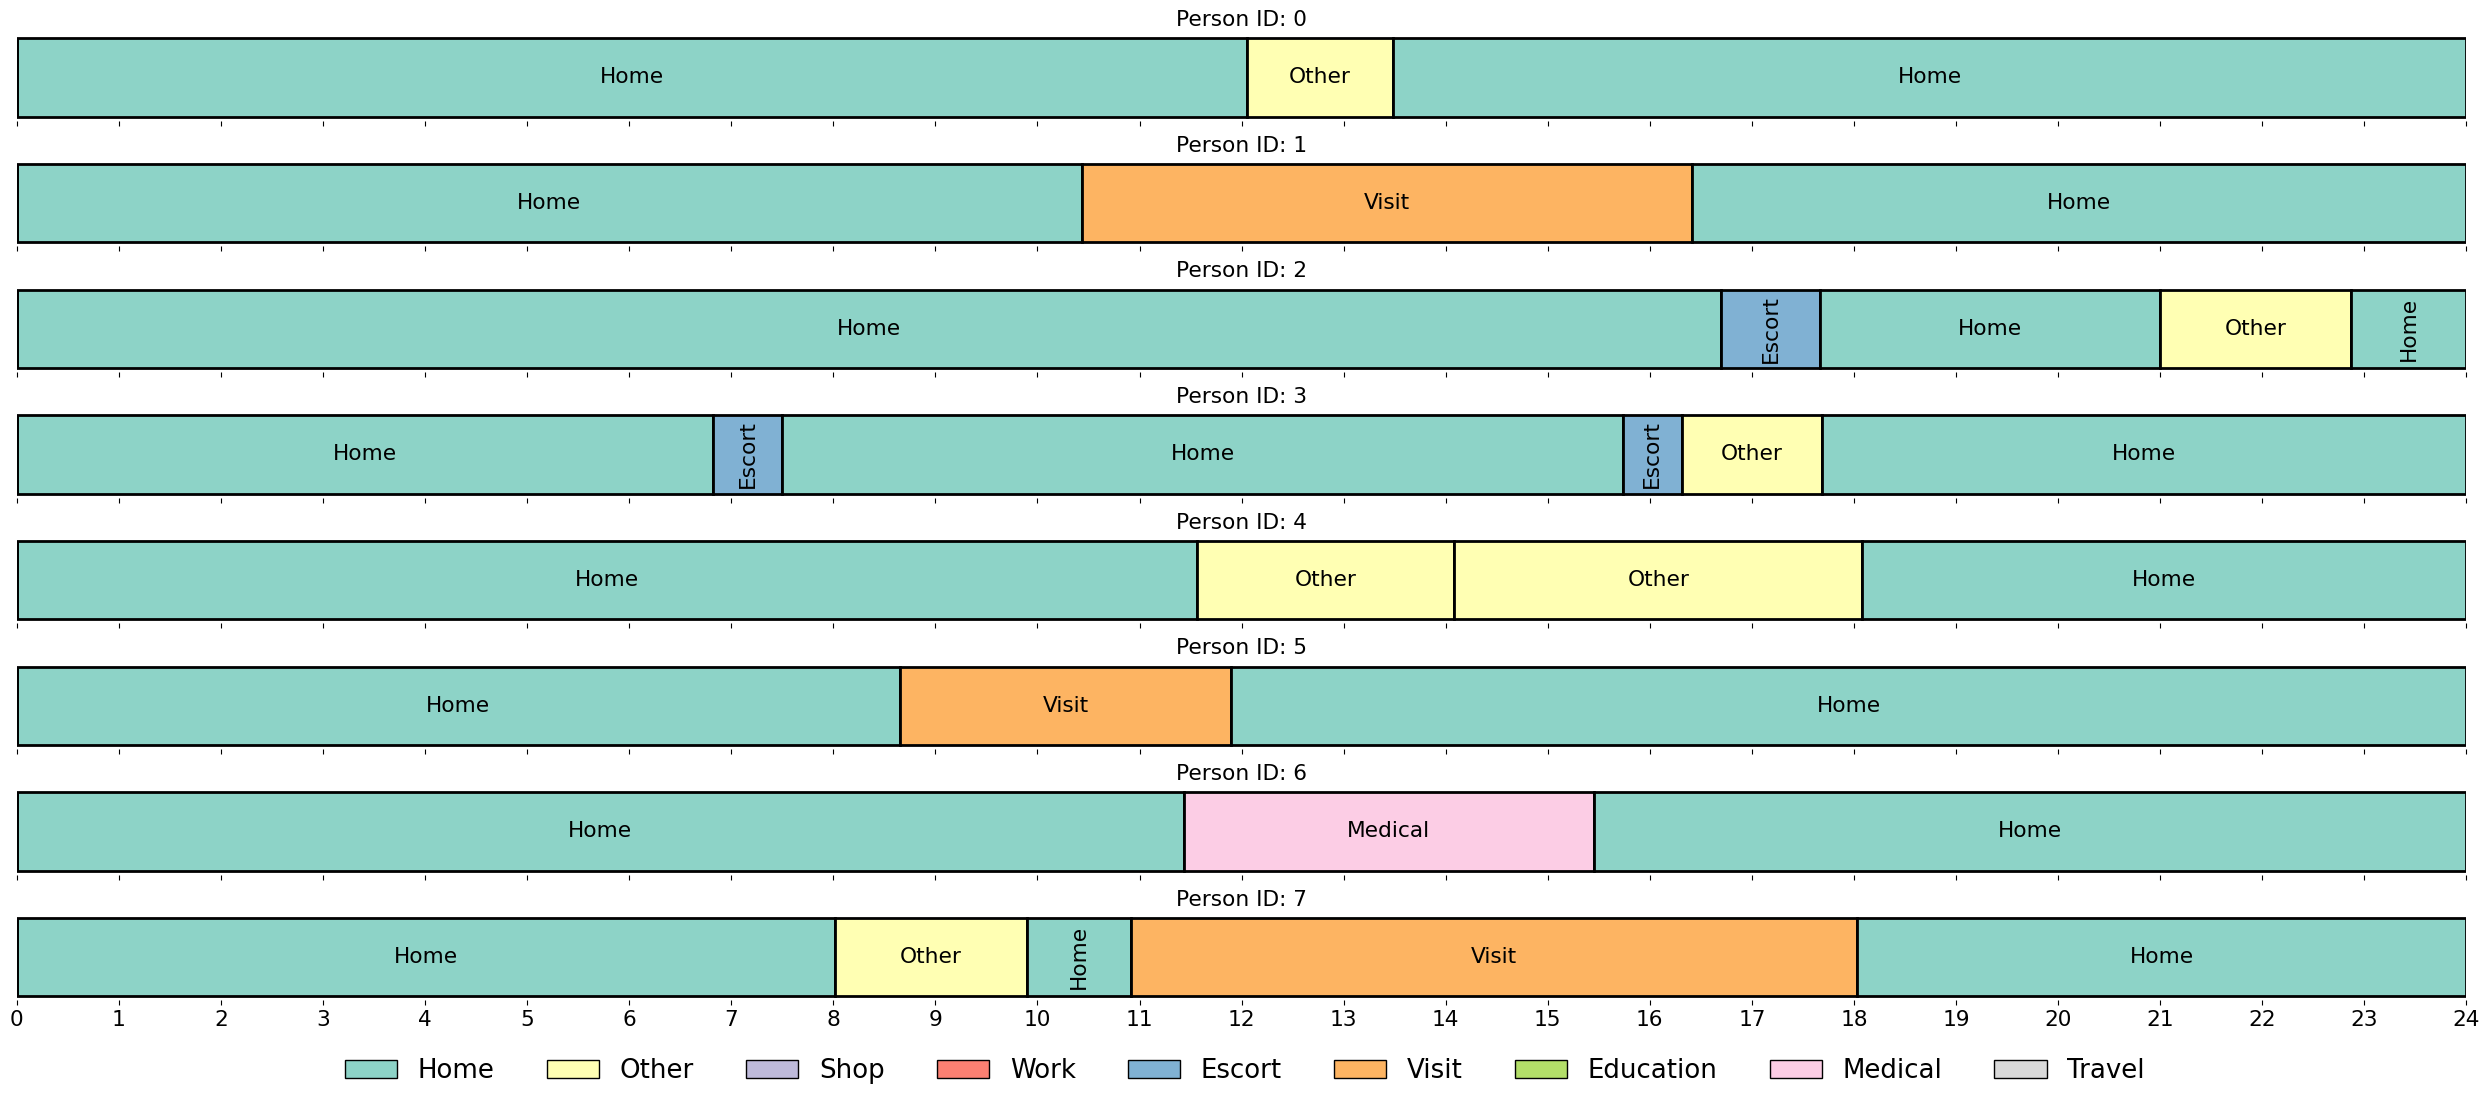

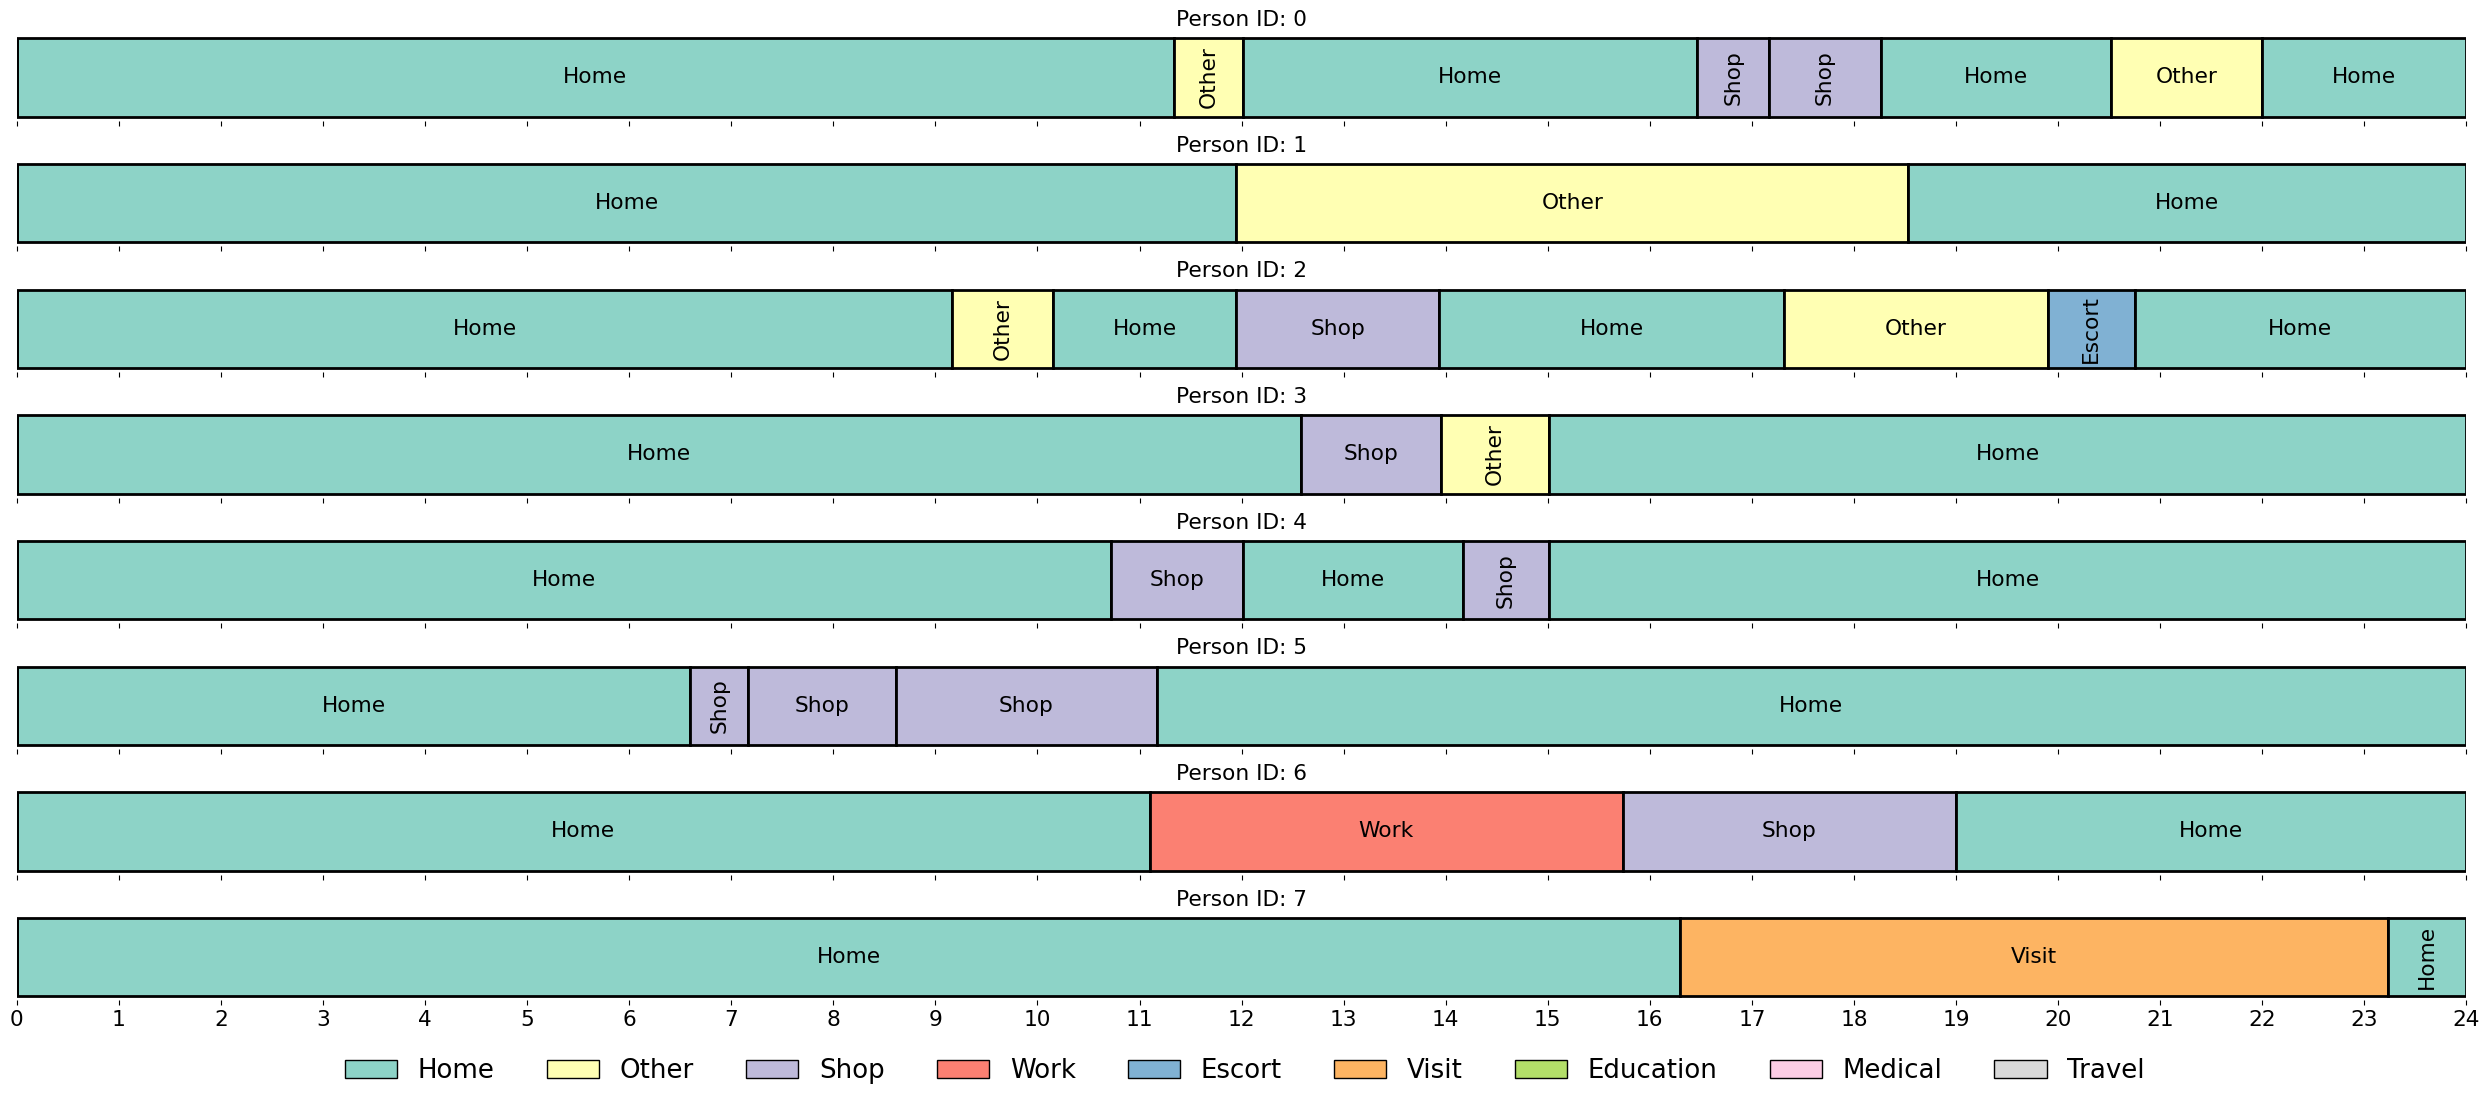

In [21]:
for n, p in batch_paths.items():
    examples = pd.read_csv(next(find_nth(p))[1] / "synthetic_schedules.csv")
    plot_schedules(examples)

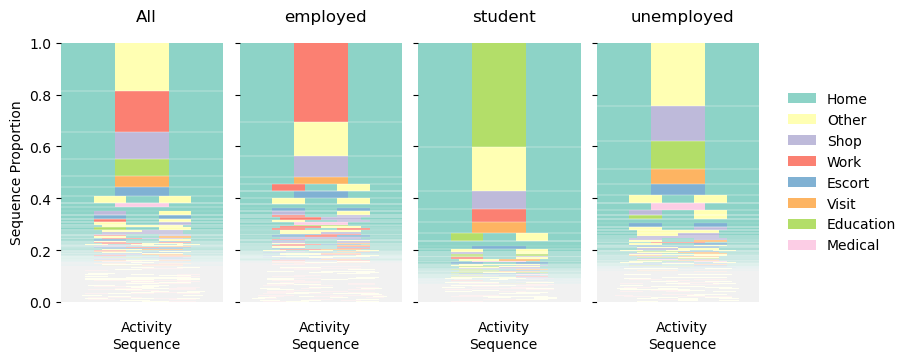

In [22]:
splits = split_on(target_schedules, target_attributes)
fig = describe_transitions.sequence_prob_plot(
    target_schedules, splits, observed_title="All", cmap=cmap, figsize=(9, 3.5)
)

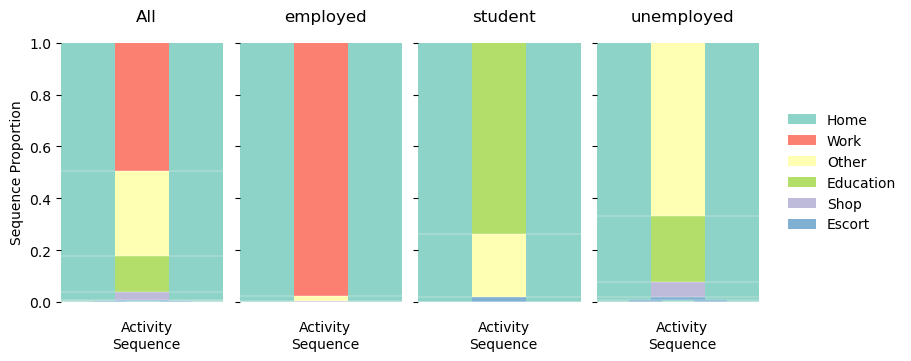

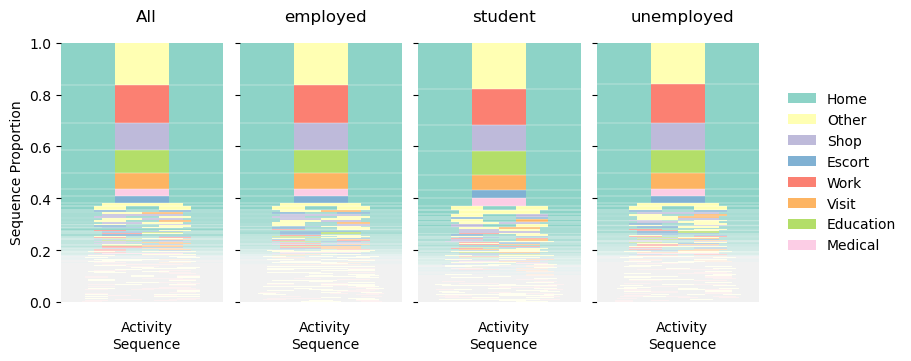

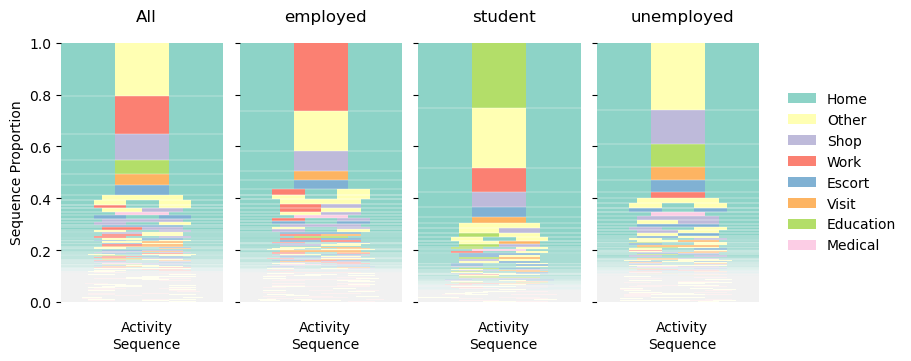

In [23]:
for k, scheds in schedules.items():
    splits = split_on(scheds, attributes[k])
    fig = describe_transitions.sequence_prob_plot(
        scheds, splits, observed_title="All", cmap=cmap, figsize=(9, 3.5)
    )

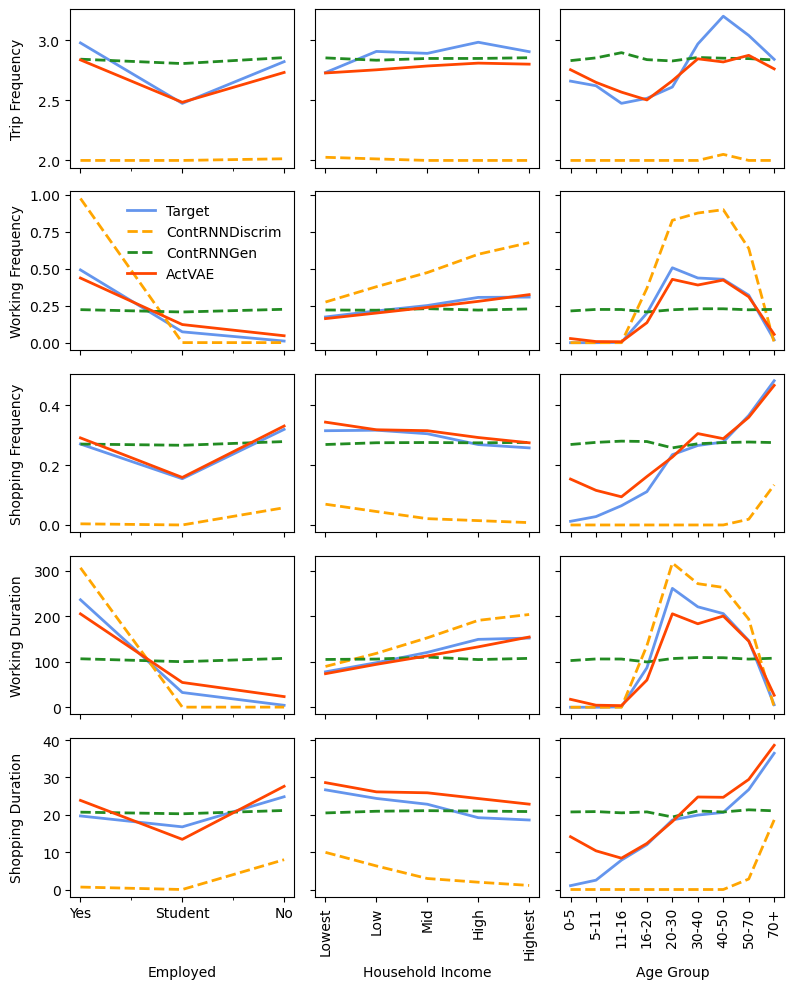

In [10]:
def duration(schedules, act="work"):
    n = schedules.pid.nunique()
    return schedules[schedules.act == act].duration.sum() / n


def count_trips(schedules):
    n = schedules.pid.nunique()
    return (len(schedules) - n) / n


def count_acts(schedules, act="work"):
    n = schedules.pid.nunique()
    return len(schedules.loc[schedules.act == act]) / n


def plot_conditionals(
    schedules, attributes, target_schedules, target_attributes, figsize=(8, 10)
):
    age_order = [
        "<5",
        "5-11",
        "11-16",
        "16-20",
        "20-30",
        "30-40",
        "40-50",
        "50-70",
        "70+",
    ]
    ages = [
        "0-5",
        "5-11",
        "11-16",
        "16-20",
        "20-30",
        "30-40",
        "40-50",
        "50-70",
        "70+",
    ]
    colours = [
        "cornflowerblue",
        "orange",
        "forestgreen",
        "orangered",
        "purple",
        "grey",
        "black",
        "lightgrey",
        "pink",
        "green",
    ]
    styles = ["-", "--", "--", "-", ":", ".-"]

    fig, axs = plt.subplots(5, 3, figsize=figsize, sharex="col", sharey="row")

    # ==============================
    # trips employment
    splits = split_on(target_schedules, target_attributes, by="work_status")
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = count_trips(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by="work_status")
        for i, split in splits.items():
            data[n][i] = count_trips(split)

    df = pd.DataFrame(data)
    ax = axs[0][0]
    df.plot(ax=ax, color=colours, style=styles, lw=2)
    ax.set_ylabel("Trip Frequency")
    ax.legend().remove()

    # ==============================
    # trips income
    splits = split_on(target_schedules, target_attributes, by="income")
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = count_trips(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by="income")
        for i, split in splits.items():
            data[n][i] = count_trips(split)

    df = pd.DataFrame(data)
    ax = axs[0][1]
    df.plot(ax=ax, color=colours, style=styles, lw=2)
    ax.legend().remove()

    # ==================================
    # trips age group
    splits = split_on(target_schedules, target_attributes, by="age_group")
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = count_trips(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by="age_group")
        for i, split in splits.items():
            data[n][i] = count_trips(split)

    df = pd.DataFrame(data)
    ax = axs[0][2]
    df.loc[age_order].plot(ax=ax, color=colours, style=styles, lw=2)
    ax.legend().remove()

    # =================================
    # work employment

    splits = split_on(target_schedules, target_attributes, by="work_status")
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = count_acts(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by="work_status")
        for i, split in splits.items():
            data[n][i] = count_acts(split)

    df = pd.DataFrame(data)
    ax = axs[1][0]
    df.plot(ax=ax, color=colours, style=styles, lw=2)
    ax.set_ylabel("Working Frequency")
    ax.legend().remove()

    # =================================
    # work income

    splits = split_on(target_schedules, target_attributes, by="income")
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = count_acts(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by="income")
        for i, split in splits.items():
            data[n][i] = count_acts(split)

    df = pd.DataFrame(data)
    ax = axs[1][1]
    df.plot(ax=ax, color=colours, style=styles, lw=2)
    ax.legend().remove()

    # ====================================
    # work age group

    splits = split_on(target_schedules, target_attributes, by="age_group")
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = count_acts(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by="age_group")
        for i, split in splits.items():
            data[n][i] = count_acts(split)

    df = pd.DataFrame(data)
    ax = axs[1][2]
    df.loc[age_order].plot(ax=ax, color=colours, style=styles, lw=2)
    ax.legend().remove()

    # =================================
    # shop employment

    splits = split_on(target_schedules, target_attributes, by="work_status")
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = count_acts(split, act="shop")

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by="work_status")
        for i, split in splits.items():
            data[n][i] = count_acts(split, act="shop")

    df = pd.DataFrame(data)
    ax = axs[2][0]
    df.plot(ax=ax, color=colours, style=styles, lw=2)
    ax.set_ylabel("Shopping Frequency")
    ax.legend().remove()

    # =================================
    # shop income

    splits = split_on(target_schedules, target_attributes, by="income")
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = count_acts(split, act="shop")

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by="income")
        for i, split in splits.items():
            data[n][i] = count_acts(split, act="shop")

    df = pd.DataFrame(data)
    ax = axs[2][1]
    df.plot(ax=ax, color=colours, style=styles, lw=2)
    ax.legend().remove()

    # ====================================
    # shop age group

    splits = split_on(target_schedules, target_attributes, by="age_group")
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = count_acts(split, act="shop")

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by="age_group")
        for i, split in splits.items():
            data[n][i] = count_acts(split, act="shop")

    df = pd.DataFrame(data)
    ax = axs[2][2]
    df.loc[age_order].plot(ax=ax, color=colours, style=styles, lw=2)
    ax.legend().remove()

    # ====================================
    # work employment

    splits = split_on(target_schedules, target_attributes, by="work_status")
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = duration(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by="work_status")
        for i, split in splits.items():
            data[n][i] = duration(split)

    df = pd.DataFrame(data)
    ax = axs[3][0]
    df.plot(ax=ax, color=colours, style=styles, lw=2)
    ax.legend().remove()
    ax.set_ylabel("Working Duration")

    # ====================================
    # work income

    splits = split_on(target_schedules, target_attributes, by="income")
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = duration(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by="income")
        for i, split in splits.items():
            data[n][i] = duration(split)

    df = pd.DataFrame(data)
    ax = axs[3][1]
    df.plot(ax=ax, color=colours, style=styles, lw=2)
    ax.legend().remove()

    # ====================================
    # work age group

    splits = split_on(target_schedules, target_attributes, by="age_group")
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = duration(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by="age_group")
        for i, split in splits.items():
            data[n][i] = duration(split)

    df = pd.DataFrame(data)
    ax = axs[3][2]
    df.loc[age_order].plot(ax=ax, color=colours, style=styles, lw=2)
    ax.legend().remove()

    # ====================================
    # shop employment

    splits = split_on(target_schedules, target_attributes, by="work_status")
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = duration(split, act="shop")

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by="work_status")
        for i, split in splits.items():
            data[n][i] = duration(split, act="shop")

    df = pd.DataFrame(data)
    ax = axs[4][0]
    df.plot(ax=ax, color=colours, style=styles, lw=2)
    ax.legend().remove()
    ax.set_ylabel("Shopping Duration")
    ax.set_xlabel("Employed")
    ax.set_xticks([0, 1, 2], ["Yes", "Student", "No"], rotation=0)

    # ====================================
    # shop income

    splits = split_on(target_schedules, target_attributes, by="income")
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = duration(split, act="shop")

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by="income")
        for i, split in splits.items():
            data[n][i] = duration(split, act="shop")

    df = pd.DataFrame(data)
    ax = axs[4][1]
    df.plot(ax=ax, color=colours, style=styles, lw=2)
    ax.legend().remove()
    ax.set_xlabel("Household Income")
    ax.set_xticks(
        [1, 2, 3, 4, 5],
        ["Lowest", "Low", "Mid", "High", "Highest"],
        rotation=90,
    )

    # ====================================
    # shop age group

    splits = split_on(target_schedules, target_attributes, by="age_group")
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = duration(split, act="shop")

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by="age_group")
        for i, split in splits.items():
            data[n][i] = duration(split, act="shop")

    df = pd.DataFrame(data)
    ax = axs[4][2]
    df.loc[age_order].plot.line(ax=ax, color=colours, style=styles, lw=2)
    ax.legend().remove()
    ax.set_xlabel("Age Group")
    ax.set_xticks(range(len(ages)), ages, rotation=90)

    # for ax in axs.flat:
    #     ax.grid(visible=True, which="major", axis="x", color="grey", linestyle="-")

    axs[1][0].legend(loc="upper right", frameon=False, fontsize=10)

    fig.align_ylabels(axs[:, 0])
    fig.align_xlabels(axs[-1, :])

    fig.tight_layout()


plot_conditionals(schedules, attributes, target_schedules, target_attributes)

In [4]:
# structure search

adds_path = Path("../logs/TRB/cvae_injection/domain_distances_subs.csv")
adds_scenario = (
    pd.read_csv(adds_path).set_index("domain").drop("observed", axis=1)
)
print(
    adds_scenario.loc[
        [
            "participations",
            "transitions",
            "timing",
            "feasibility",
            "creativity",
        ],
        # ["s200", "s100", "s50", "s25", "s12"],
    ].to_latex(float_format="{:.3f}".format)
)
adds_scenario

\begin{tabular}{lrrrrrrrrr}
\toprule
 & nn & na & nc & an & aa & ac & cn & ca & cc \\
domain &  &  &  &  &  &  &  &  &  \\
\midrule
participations & 0.095 & 0.097 & 0.078 & 0.059 & 0.075 & 0.085 & 0.068 & 0.096 & 0.078 \\
transitions & 0.010 & 0.008 & 0.005 & 0.005 & 0.006 & 0.006 & 0.006 & 0.012 & 0.006 \\
timing & 0.050 & 0.059 & 0.033 & 0.028 & 0.058 & 0.030 & 0.031 & 0.068 & 0.033 \\
feasibility & 0.026 & 0.014 & 0.013 & 0.038 & 0.027 & 0.021 & 0.019 & 0.028 & 0.034 \\
creativity & 0.009 & 0.037 & 0.009 & 0.012 & 0.038 & 0.009 & 0.014 & 0.045 & 0.011 \\
\bottomrule
\end{tabular}



,nn,na,nc,an,aa,ac,cn,ca,cc
domain,,,,,,,,,
creativity,0.008581,0.036600,0.008940,0.011553,0.038062,0.009409,0.013666,0.044794,0.010616
feasibility,0.025549,0.014115,0.012820,0.037994,0.027479,0.020598,0.019351,0.028355,0.033649
participations,0.094938,0.096936,0.077541,0.059268,0.075274,0.084583,0.067534,0.095941,0.077909
timing,0.049517,0.058565,0.032580,0.027505,0.057867,0.029841,0.031293,0.068238,0.033217
transitions,0.009635,0.007527,0.004960,0.004635,0.005792,0.005882,0.006167,0.012176,0.006143


In [12]:
names = ["aa", "ac", "an", "ca", "cc", "cn"]
structure_schedules = {}
structure_attributes = {}
for name in names:
    structure_schedules[name] = pd.read_csv(
        latest(Path(f"../logs/TRB/cvae_injection/{name}"))[1]
        / "synthetic_schedules.csv"
    )
    structure_attributes[name] = pd.read_csv(
        latest(Path(f"../logs/TRB/cvae_injection/{name}"))[1]
        / "synthetic_attributes.csv"
    )

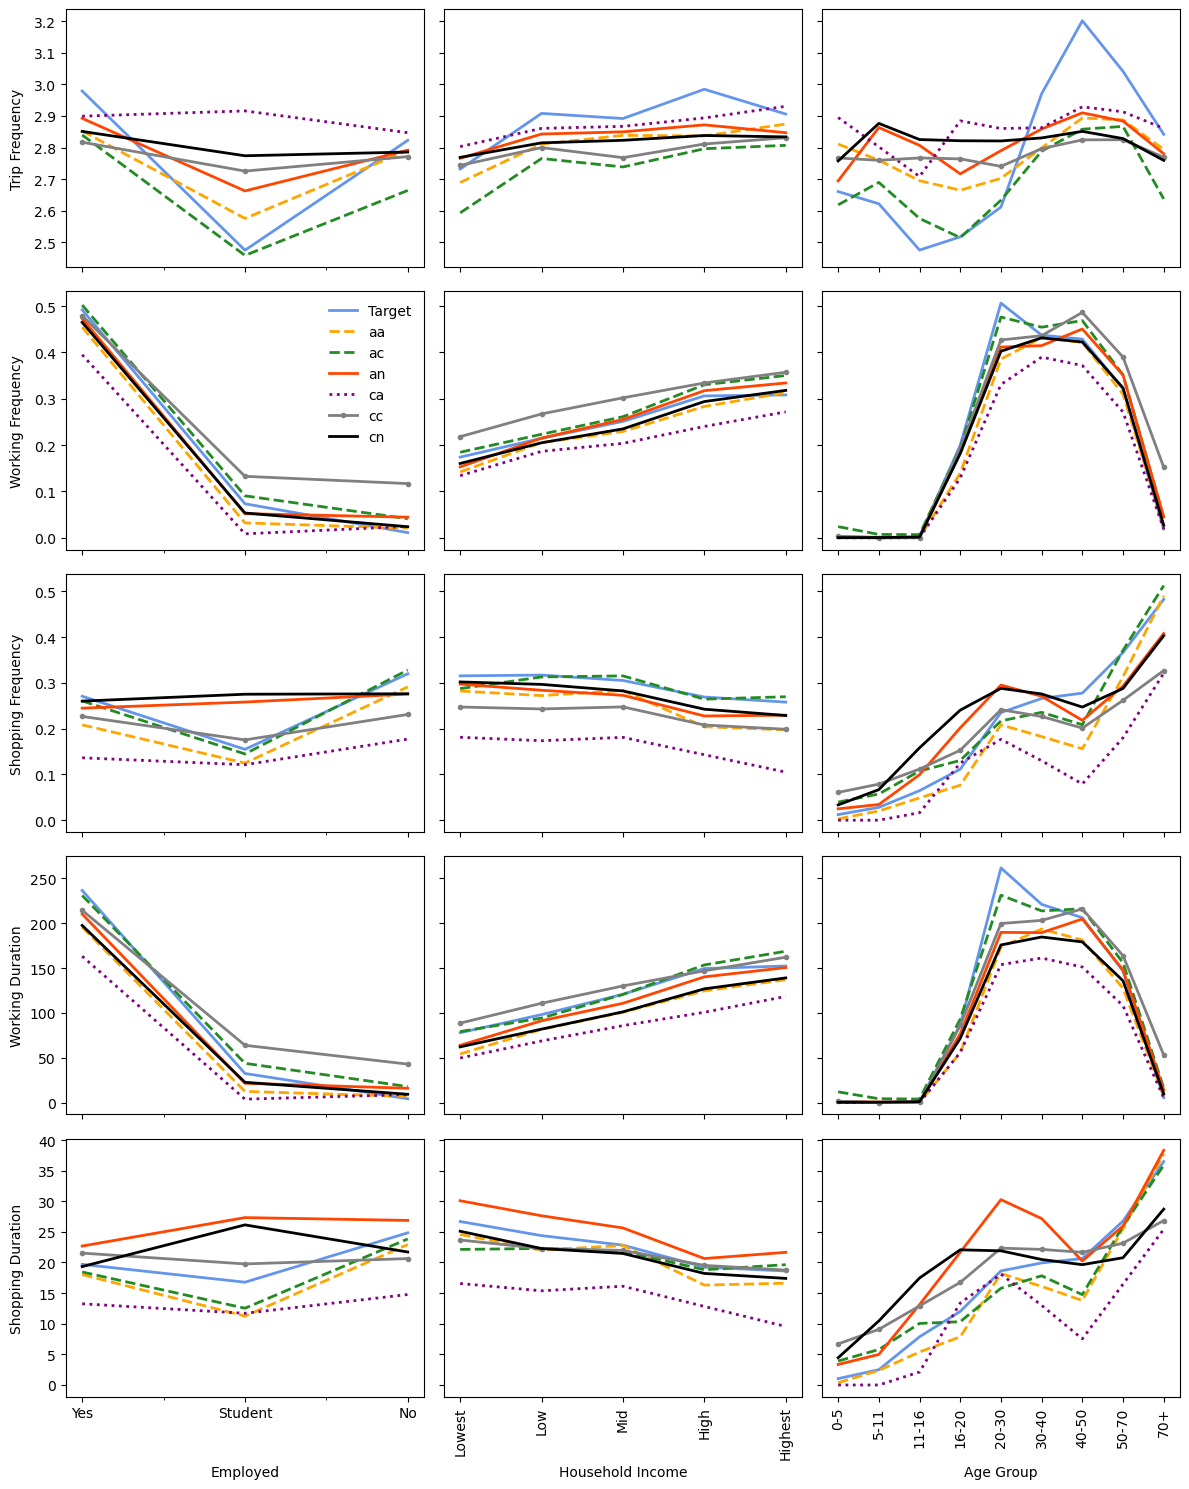

In [13]:
plot_conditionals(
    structure_schedules,
    structure_attributes,
    target_schedules,
    target_attributes,
    figsize=(12, 15),
)

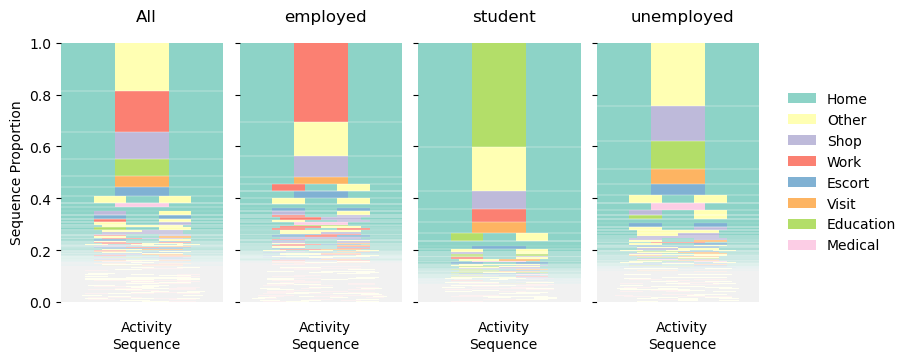

In [14]:
splits = split_on(target_schedules, target_attributes)
fig = describe_transitions.sequence_prob_plot(
    target_schedules, splits, observed_title="All", cmap=cmap, figsize=(9, 3.5)
)

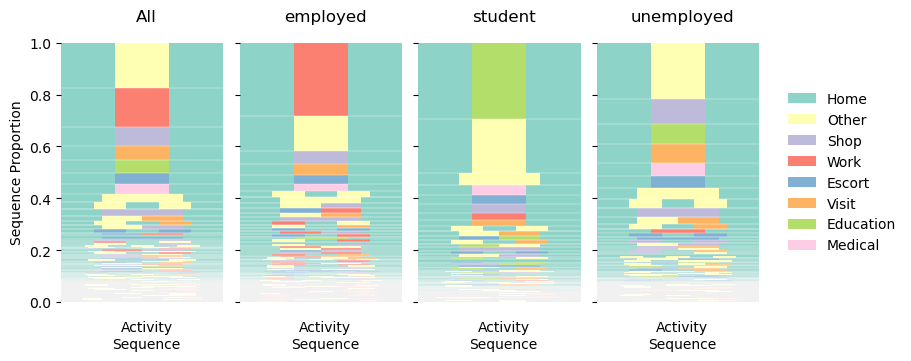

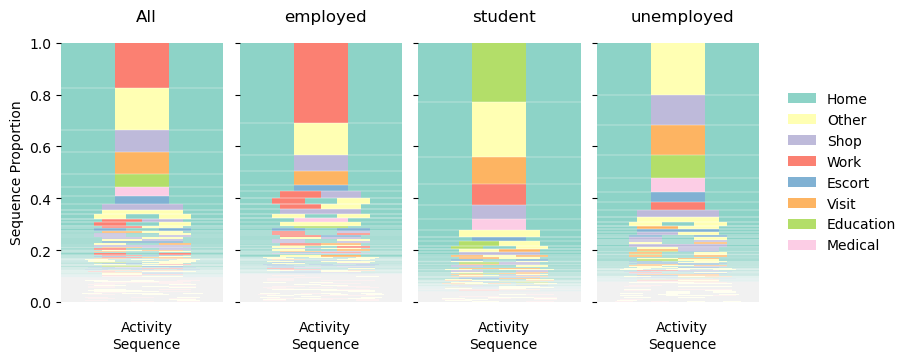

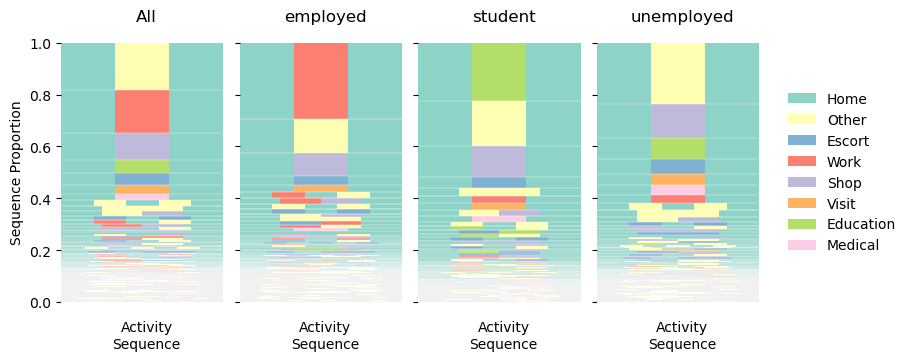

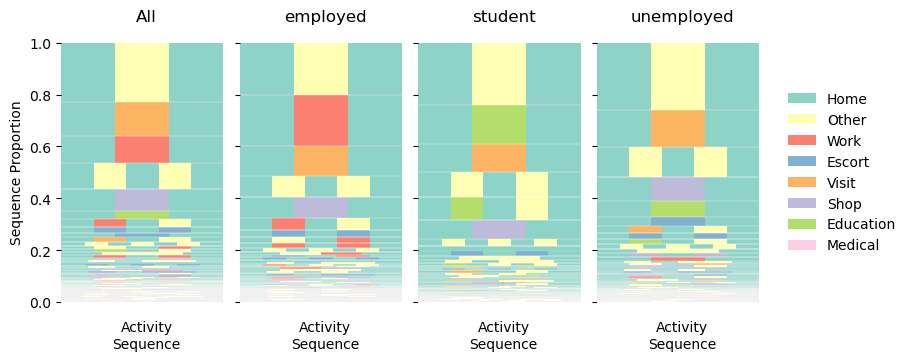

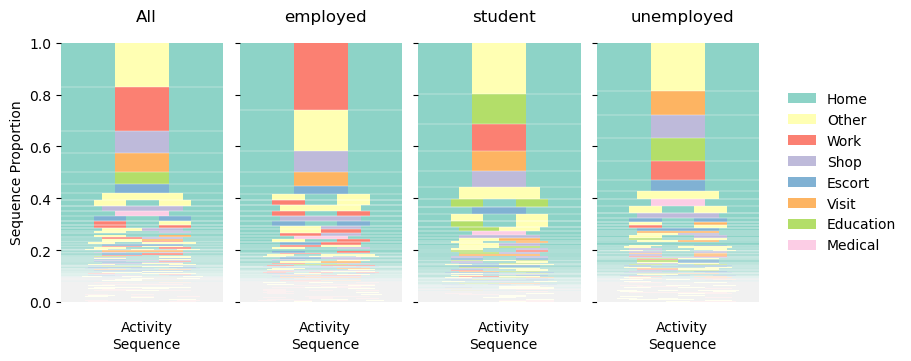

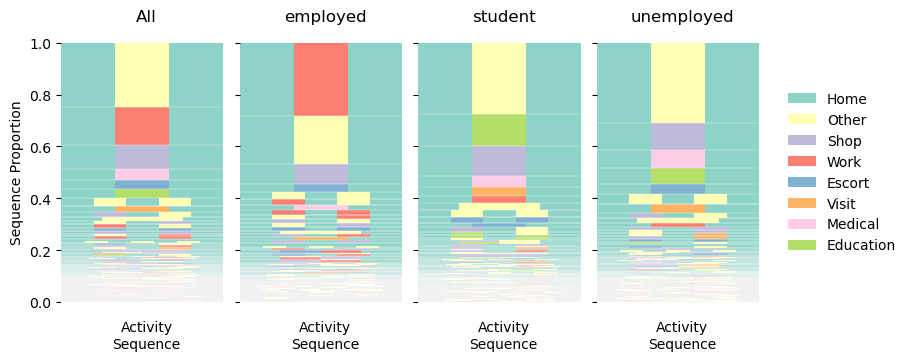

In [15]:
for k, scheds in structure_schedules.items():
    splits = split_on(scheds, structure_attributes[k])
    fig = describe_transitions.sequence_prob_plot(
        scheds, splits, observed_title="All", cmap=cmap, figsize=(9, 3.5)
    )

In [ ]:
# Ageing Scenario
attributes = {
    2023: pd.read_csv(Path("../tmp/nomis_ages_2023.csv")),
    2030: pd.read_csv(Path("../tmp/nomis_ages_2030.csv")),
    2040: pd.read_csv(Path("../tmp/nomis_ages_2040.csv")),
    2050: pd.read_csv(Path("../tmp/nomis_ages_2050.csv")),
}
demographics = pd.DataFrame(
    {year: a.age_group.value_counts() for year, a in attributes.items()}
).loc[
    ["<5", "5-11", "11-16", "16-20", "20-30", "30-40", "40-50", "50-70", "70+"]
]
print(demographics.sum(axis=0))
demographics

In [ ]:
scaled = demographics * 100 / 1000000

fig, ax = plt.subplots(figsize=(6, 3))

# Use a colorblind-friendly palette from matplotlib
colors = [
    "#0072B2",
    "#009E73",
    "#D55E00",
    "#CC79A7",
]  # blue, green, orange, purple
linestyles = ["-", "-.", "--", ":"]

for year, c, linestyle in zip([2023, 2030, 2040, 2050], colors, linestyles):
    ax.plot(
        scaled[year],
        scaled.index,
        label=str(year),
        color=c,
        linestyle=linestyle,
        linewidth=2,
    )
for y in scaled.index:
    ax.axhline(y, color="lightgrey", linestyle="--", linewidth=0.5, zorder=0)

ax.set_xlabel("Count (millions)")
ax.set_ylabel("Age Group")
ax.legend(scaled.columns, loc="lower right", frameon=False, title_fontsize=12)
ax.set_xlim(0, 20)

In [ ]:
aged_schedule_paths = {
    n[1:]: Path("../logs/TRB/cvae_nomis_scenario") / n / "version_1"
    for n in ["a2023", "a2030", "a2040", "a2050"]
}
age_schedules = {
    n: pd.read_csv(p / "synthetic_schedules.csv")
    for n, p in aged_schedule_paths.items()
}
age_attributes = {
    n: pd.read_csv(p / "synthetic_attributes.csv")
    for n, p in aged_schedule_paths.items()
}
age_target = age_schedules.pop("2023")
age_attributes_target = age_attributes.pop("2023")

In [ ]:
fig = frequency_plots(
    age_target,
    age_schedules,
    color=cmap,
    figsize=(8, 3.5),
    observed_title="Target",
)
fig = sequence_prob_plot(
    age_target,
    age_schedules,
    cmap=cmap,
    figsize=(8, 3.5),
    observed_title="2023",
)

In [ ]:
# for k, scheds in age_schedules.items():
#     splits = split_on(scheds, age_attributes[k], by="age_group")
#     fig = describe_transitions.sequence_prob_plot(
#         scheds, splits, observed_title="All", cmap=cmap, figsize=(16, 3.5)
#     )

In [ ]:
aged_scenario = Path(
    "../logs/TRB/cvae_nomis_scenario/label_descriptions_subs.csv"
)
aged_scenario = pd.read_csv(aged_scenario)
aged_scenario.set_index(["domain", "feature", "segment", "cat"], inplace=True)
aged_scenario = aged_scenario.loc[
    ("participations", "participation rate"),
    ["a2023", "a2030", "a2040", "a2050"],
]
aged_scenario = aged_scenario.reset_index()
aged_scenario = aged_scenario.loc[aged_scenario.segment == "education"].drop(
    "segment", axis=1
)
aged_scenario = aged_scenario.set_index("cat")
aged_scenario = aged_scenario.loc[
    ["<5", "5-11", "11-16", "16-20", "20-30", "30-40", "40-50", "50-70", "70+"]
]
# aged_scenario = aged_scenario.pivot(columns="cat")
aged_scenario

In [ ]:
aged_scenario = Path("../logs/TRB/cvae_nomis_scenario/descriptions.csv")
aged_scenario = pd.read_csv(aged_scenario)
aged_scenario.set_index(["domain", "feature", "segment"], inplace=True)
aged_scenario = aged_scenario.loc[
    ("participations"), ["a2023", "a2030", "a2040", "a2050"]
]
aged_scenario = aged_scenario.drop("pair participation rate", axis=0)
aged_scenario

In [ ]:
aged_scenario = Path("../logs/TRB/cvae_nomis_scenario/descriptions.csv")
aged_scenario = pd.read_csv(aged_scenario)
aged_scenario.set_index(["domain", "feature", "segment"], inplace=True)
aged_scenario = aged_scenario.loc[
    ("participations"), ["a2023", "a2030", "a2040", "a2050"]
]
# aged_scenario = aged_scenario.loc["participation rate"]
aged_scenario = aged_scenario.drop("pair participation rate", axis=0)
for c in ["a2030", "a2040", "a2050"]:
    aged_scenario[c] = aged_scenario[c].astype(float)
    aged_scenario[f"{c}"] = (
        100
        * (aged_scenario[c] - aged_scenario["a2023"])
        / aged_scenario["a2023"]
    )
aged_scenario = aged_scenario.sort_values(by="a2023", ascending=False)
print(
    aged_scenario.to_latex(
        float_format="{:.3f}".format, index=True, label="tab:aged_scenario"
    )
)
aged_scenario

In [ ]:
schedules = {
    year: pd.read_csv(
        latest(Path("../logs/TRB/cvae_ageing_scenario") / f"a{year}")[1]
        / "synthetic_schedules.csv"
    )
    for year in ["2023", "2033", "2043", "2053"]
}

base = schedules.pop("2023")

fig = joint_time_distributions_plot(
    base,
    schedules,
    figsize=(8, 6),
    observed_title="2023",
    cmaps={
        0: "Blues",
        1: "Oranges",
        2: "Greens",
        3: "Reds",
        4: "Purples",
        5: "Greys",
    },
)
fig = frequency_plots(
    base, schedules, color=cmap, figsize=(8, 3.5), observed_title="2023"
)
fig = describe_transitions.sequence_prob_plot(
    base, schedules, observed_title="2023", cmap=cmap, figsize=(8, 3.5)
)

In [ ]:
# Sampling Scenario

sample_scenario = Path("../logs/TRB/cvae_sampled_scenario/domain_distances.csv")
sample_scenario = (
    pd.read_csv(sample_scenario).set_index("domain").drop("observed", axis=1)
)
print(
    sample_scenario.loc[
        [
            "participations",
            "transitions",
            "timing",
            "feasibility",
            "creativity",
        ],
        ["s200", "s100", "s50", "s25", "s12"],
    ].to_latex(float_format="{:.3f}".format)
)

In [ ]:
sample_scenario = Path(
    "../logs/TRB/cvae_sampled_scenario/domain_distances_subs.csv"
)
sample_scenario = (
    pd.read_csv(sample_scenario).set_index("domain").drop("observed", axis=1)
)
print(
    sample_scenario.loc[
        [
            "participations",
            "transitions",
            "timing",
            "feasibility",
            "creativity",
        ],
        ["s200", "s100", "s50", "s25", "s12"],
    ].to_latex(float_format="{:.3f}".format)
)

In [ ]:
s200 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_sampled_scenario/s200"))[1]
    / "synthetic_schedules.csv"
)
s100 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_sampled_scenario/s100"))[1]
    / "synthetic_schedules.csv"
)

s50 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_sampled_scenario/s50"))[1]
    / "synthetic_schedules.csv"
)
s25 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_sampled_scenario/s25"))[1]
    / "synthetic_schedules.csv"
)
s12 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_sampled_scenario/s12"))[1]
    / "synthetic_schedules.csv"
)
# s6 = pd.read_csv(
#     latest(Path("../logs/TRB/cvae_sampled_scenario/s6"))[1]
#     / "synthetic_schedules.csv"
# )

sampled_schedules = {
    "200k": s200,
    "100k": s100,
    "50k": s50,
    "25k": s25,
    "12.5k": s12,
}

fig = times_distributions_plot(
    target_schedules, sampled_schedules, observed_title="Target", figsize=(9, 5)
)
fig = frequency_plots(
    target_schedules,
    sampled_schedules,
    color=cmap,
    figsize=(9, 3.5),
    observed_title="Target",
)
fig = describe_transitions.sequence_prob_plot(
    target_schedules,
    sampled_schedules,
    observed_title="Target",
    cmap=cmap,
    figsize=(9, 3.5),
)

In [ ]:
# labels scenario
label_scenario = Path("../logs/TRB/cvae_labels_scenario/domain_distances.csv")
label_scenario = (
    pd.read_csv(label_scenario).set_index("domain").drop("observed", axis=1)
)
print(
    label_scenario.loc[
        ["participations", "transitions", "timing", "feasibility", "creativity"]
    ].to_latex(float_format="{:.3f}".format)
)
label_scenario[["l1", "l2", "l4", "l8", "l16"]]

In [ ]:
label_scenario = Path(
    "../logs/TRB/cvae_labels_scenario/domain_distances_subs.csv"
)
label_scenario = (
    pd.read_csv(label_scenario).set_index("domain").drop("observed", axis=1)
)
print(
    label_scenario.loc[
        ["participations", "transitions", "timing", "feasibility", "creativity"]
    ].to_latex(float_format="{:.3f}".format)
)
label_scenario[["l1", "l2", "l4", "l8"]]

In [ ]:
label_scenario = Path(
    "../logs/TRB/cvae_labels_scenario/label_descriptions_subs.csv"
)
label_scenario = pd.read_csv(label_scenario)
label_scenario = label_scenario.loc[
    label_scenario.cat.isin(["employed", "unemployed"])
]
label_scenario = label_scenario.set_index(
    ["domain", "feature", "segment", "label", "cat"]
).drop("unit", axis=1)


def aggregate_label_scenario(label_scenario):
    agg = {}
    for c in ["observed", "l1", "l2", "l4", "l8"]:
        agg[c] = (
            label_scenario[c] * label_scenario[f"{c}__weight"]
        ).sum() / label_scenario[f"{c}__weight"].sum()
    return pd.Series(agg)


label_scenario.groupby(["domain", "cat"]).apply(aggregate_label_scenario)

In [ ]:
l1 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_labels_scenario/l1"))[1]
    / "synthetic_schedules.csv"
)

l2 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_labels_scenario/l2"))[1]
    / "synthetic_schedules.csv"
)
l4 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_labels_scenario/l4"))[1]
    / "synthetic_schedules.csv"
)
l8 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_labels_scenario/l8"))[1]
    / "synthetic_schedules.csv"
)
l16 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_labels_scenario/l16"))[1]
    / "synthetic_schedules.csv"
)

sampled_schedules = {"L=1": l1, "L=2": l2, "L=4": l4, "L=8": l8, "L=16": l16}

fig = times_distributions_plot(
    target_schedules, sampled_schedules, observed_title="Target", figsize=(9, 5)
)
fig = frequency_plots(
    target_schedules,
    sampled_schedules,
    color=cmap,
    figsize=(9, 3.5),
    observed_title="Target",
)
fig = describe_transitions.sequence_prob_plot(
    target_schedules,
    sampled_schedules,
    observed_title="Target",
    cmap=cmap,
    figsize=(9, 3.5),
)

In [ ]:
# transfer scenario
label_scenario = Path("../logs/TRB/cvae_transfer_scenario/domain_distances.csv")
label_scenario = (
    pd.read_csv(label_scenario).set_index("domain").drop("observed", axis=1)
)
print(
    label_scenario.loc[
        [
            "participations",
            "transitions",
            "timing",
            "feasibility",
            "creativity",
        ],
        ["1yr_base", "transfer"],
    ].to_latex(float_format="{:.3f}".format)
)

label_scenario = Path(
    "../logs/TRB/cvae_transfer_scenario/domain_distances_subs.csv"
)
label_scenario = (
    pd.read_csv(label_scenario).set_index("domain").drop("observed", axis=1)
)
print(
    label_scenario.loc[
        [
            "participations",
            "transitions",
            "timing",
            "feasibility",
            "creativity",
        ],
        ["1yr_base", "transfer"],
    ].to_latex(float_format="{:.3f}".format)
)
label_scenario

In [ ]:
for n in ["aggregate", "participations", "transitions", "timing"]:
    print(n)
    print(table.loc[n].to_latex(float_format="{:.3f}".format))
    print()

In [ ]:
def build_creativity_table(batch_paths):
    descriptions_combined = pd.DataFrame()
    distances_combined = pd.DataFrame()

    for name, path in batch_paths.items():

        descriptions = (
            pd.read_csv(path / "descriptions.csv")
            .set_index(["domain", "feature", "segment"])
            .loc["creativity"]
        )
        distances = (
            pd.read_csv(path / "distances.csv")
            .set_index(["domain", "feature", "segment"])
            .loc["creativity"]
        )

        columns = set(descriptions.columns)
        weights = set([c for c in columns if "weight" in c])
        columns = list(
            columns
            - set(["observed", "description", "mean", "std", "feature count"])
            - weights
        )

        descriptions_combined[name, "desc."] = descriptions[columns].mean(
            axis=1
        )

        distances_combined[name, "dist."] = distances[columns].mean(axis=1)

    descriptions_combined["Observed", ""] = descriptions["observed"]
    descriptions_combined["Description", ""] = descriptions["description"]

    print(descriptions_combined.columns)

    descriptions_combined.columns = pd.MultiIndex.from_tuples(
        descriptions_combined.columns
    )

    distances_combined["Observed", ""] = distances["observed"]
    distances_combined["Description", ""] = distances["distance"]

    distances_combined.columns = pd.MultiIndex.from_tuples(
        distances_combined.columns
    )

    order = list(descriptions_combined.columns)
    order.pop(order.index(("Observed", "")))
    order.pop(order.index(("Description", "")))
    order = [("Observed", "")] + order + [("Description", "")]
    descriptions_combined = descriptions_combined.loc[:, order]

    order = list(distances_combined.columns)
    order.pop(order.index(("Observed", "")))
    order.pop(order.index(("Description", "")))
    order = [("Observed", "")] + order + [("Description", "")]
    distances_combined = distances_combined.loc[:, order]

    return pd.concat((descriptions_combined, distances_combined), axis=0)


table = build_creativity_table(batch_paths)
table

In [ ]:
print(table.loc["sample quality"].to_latex(float_format="{:.3f}".format))
table.loc["sample quality"]

In [ ]:
table.loc["creativity"]

In [ ]:
print(table.to_latex(float_format="{:.3f}".format))

In [ ]:
for domain in [
    "creativity",
    "sample quality",
    "aggregate",
    "participations",
    "transitions",
    "timing",
]:
    print()
    print(domain)
    print()
    ss = table.loc[domain]
    for feature in set(ss.reset_index()["feature"]):
        print(feature)
        print()
        print(ss.loc[feature].to_latex(float_format="{:.3f}".format))

In [ ]:
def build_subs_description_tables(batch_paths):
    descriptions_combined = pd.DataFrame()

    for name, path in batch_paths.items():

        descriptions = pd.read_csv(path / "descriptions_subs.csv").set_index(
            ["domain", "feature", "segment", "sub_pop"]
        )
        columns = set(descriptions.columns)
        columns = list(
            columns
            - set(["observed", "description", "mean", "std", "feature count"])
        )

        descriptions_combined[name] = descriptions[columns].mean(axis=1)

    descriptions_combined["Observed"] = descriptions["observed"]
    descriptions_combined["Description"] = descriptions["description"]

    descriptions_combined = (
        descriptions_combined.sort_values("Observed", ascending=False)
        .groupby(["domain", "feature", "sub_pop"])
        .head(100)
    )

    order = list(descriptions_combined.columns)
    order.pop(order.index("Observed"))
    order = ["Observed"] + order

    index = [
        "creativity",
        "sample quality",
        "aggregate",
        "participations",
        "transitions",
        "timing",
    ]

    return descriptions_combined.loc[index, order]


table = build_subs_description_tables(batch_paths)
table

In [ ]:
table.loc[
    "participations",
    "participation rate",
    "work0",
    ["work_status=student", "work_status=employed"],
]

In [ ]:
table.loc[
    "participations",
    "participation rate",
    "education0",
    ["work_status=student", "work_status=employed"],
]